# Intro

This notebook provides a descriptive analysis of behavior and walks through observations that contextualize later analysis. As in the `Data Cleaning` notebook, the emphasis will be on the pushes instead of the continuous variables.

##  Setup

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize_scalar, fsolve
from scipy.stats import gamma

from foraging import plotting
from foraging import utils
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split

from foraging.plotting import bp, per_block, enhanced_violinplot, titler, plot_variable_subplots
from foraging.plotting.behavior import plot_block_events, plot_pushes, plot_wait_times, plot_runlengths, \
    plot_experiment_parameters, plot_experiment_overview, plot_push_intervals_vs_reward_intervals, \
    plot_stay_switch_pushes, plot_next_push_surprise, plot_stay_probabilities, plot_reward_rates_in_block, \
    plot_quantity_in_block, plot_matching_law
from foraging.utils.beliefs import compute_reward_probabilities, compute_fisher, compute_normalized_fisher
from foraging.utils.data import make_df, exclusion_criteria, filter_df, display_df, get_blocks, bin_data, process_blocks, extend_df
from foraging.utils import stats
from foraging.config.constants import BOX_COLORS, BOX_LABELS, KAPPA_LEVELS, SEED
from foraging.plotting import PALETTE, PALETTE_DARK
from foraging.utils import INDEX, MIN_INDEX
from functools import partial

# Filter out annoying matplotlib logs
mlogger = logging.getLogger('matplotlib')
mlogger.setLevel(logging.WARNING)

# constants
RNG = np.random.default_rng(SEED)
DATA_DIR = '../data'
FIGURES_DIR = '../figures'

# Load Data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is given in the `Data Cleaning` notebook.

Here is a DataFrame showing a subset of the data, after applying the exclusion criteria detailed in `Data Cleaning`. Refer to the docstring of `make_df` and `exclusion_criteria` for more information about the contents of the DataFrame.

In [2]:
df = make_df(os.path.join(DATA_DIR, 'experiments'))
df = exclusion_criteria(df)
display_df(df, ["box", "push times", "reward outcomes"])

|                                                               | box    |   push times | reward outcomes   |
|:--------------------------------------------------------------|:-------|-------------:|:------------------|
| ('dylan', 20211206, 2, 1, 'probability', 1, 'high', 0.1, 'M') | slow   |        3.135 | False             |
| ('dylan', 20211206, 2, 2, 'probability', 1, 'high', 0.1, 'M') | fast   |        8.465 | False             |
| ('dylan', 20211206, 2, 3, 'probability', 1, 'high', 0.1, 'M') | fast   |        9.468 | False             |
| ('dylan', 20211206, 2, 4, 'probability', 1, 'high', 0.1, 'M') | fast   |       11.667 | False             |
| ('dylan', 20211206, 2, 5, 'probability', 1, 'high', 0.1, 'M') | medium |       17.125 | False             |

## Data Overview
A quick overview of the summary statistics:

In [3]:
print("schedules experienced by each subject")
print(df.groupby('subject')['schedule'].unique())

schedules experienced by each subject
subject
dylan                      [35.0, 15.0, 21.0]
humans                      [14.0, 21.0, 7.0]
marco                [35.0, 15.0, 21.0, 30.0]
viktor    [15.0, 21.0, 35.0, 28.0, 7.0, 14.0]
Name: schedule, dtype: object


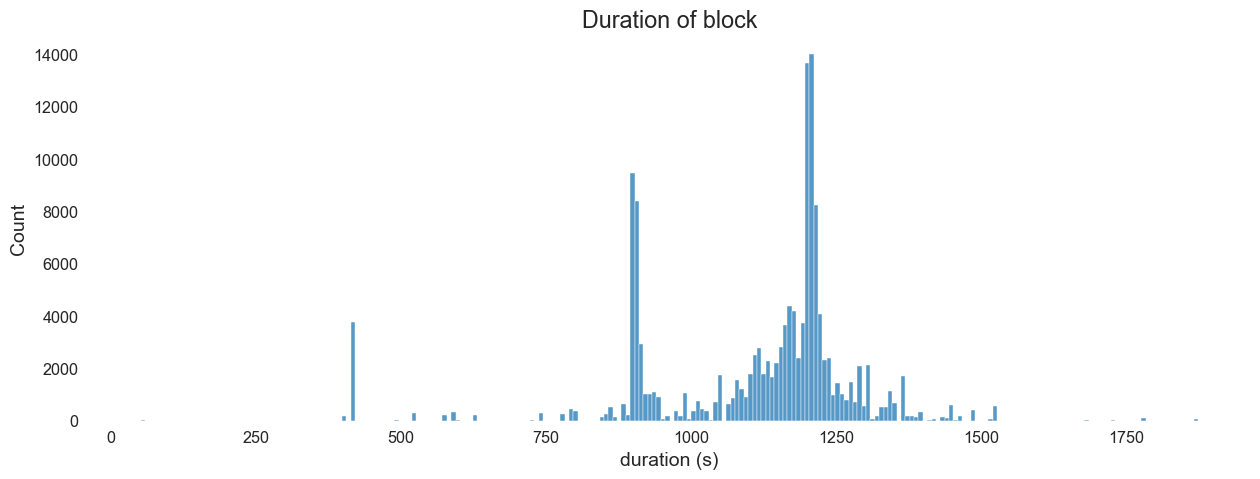

In [3]:
sns.histplot(df, x = 'duration')
plt.title("Duration of block")
plt.xlabel("duration (s)");

<Axes: xlabel='subject', ylabel='n pushes per block'>

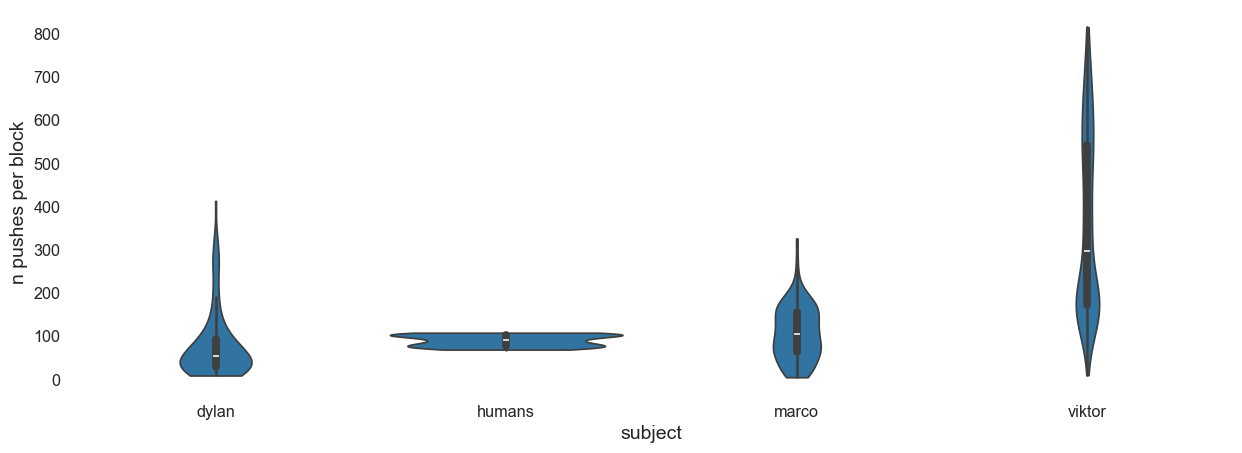

In [3]:
block_summary = df.groupby(['subject', 'session', 'block']).size().reset_index(name='n pushes per block')
sns.violinplot(block_summary, x='subject', y='n pushes per block', cut=0)
plt.title("# pushes per block");

Here is a bird's eye view of one subject's behavioral data over the course of the entire experiment. Each row is a session of consecutive blocks. Each block's pushes are displayed as a raster plot over the duration of that block, and the pushes at each box position are stacked on top of each other (top to bottom is 3, 2, 1). Finally, pushes are colored by box schedule, so we can see how the schedules are assigned to each box over consecutive blocks.

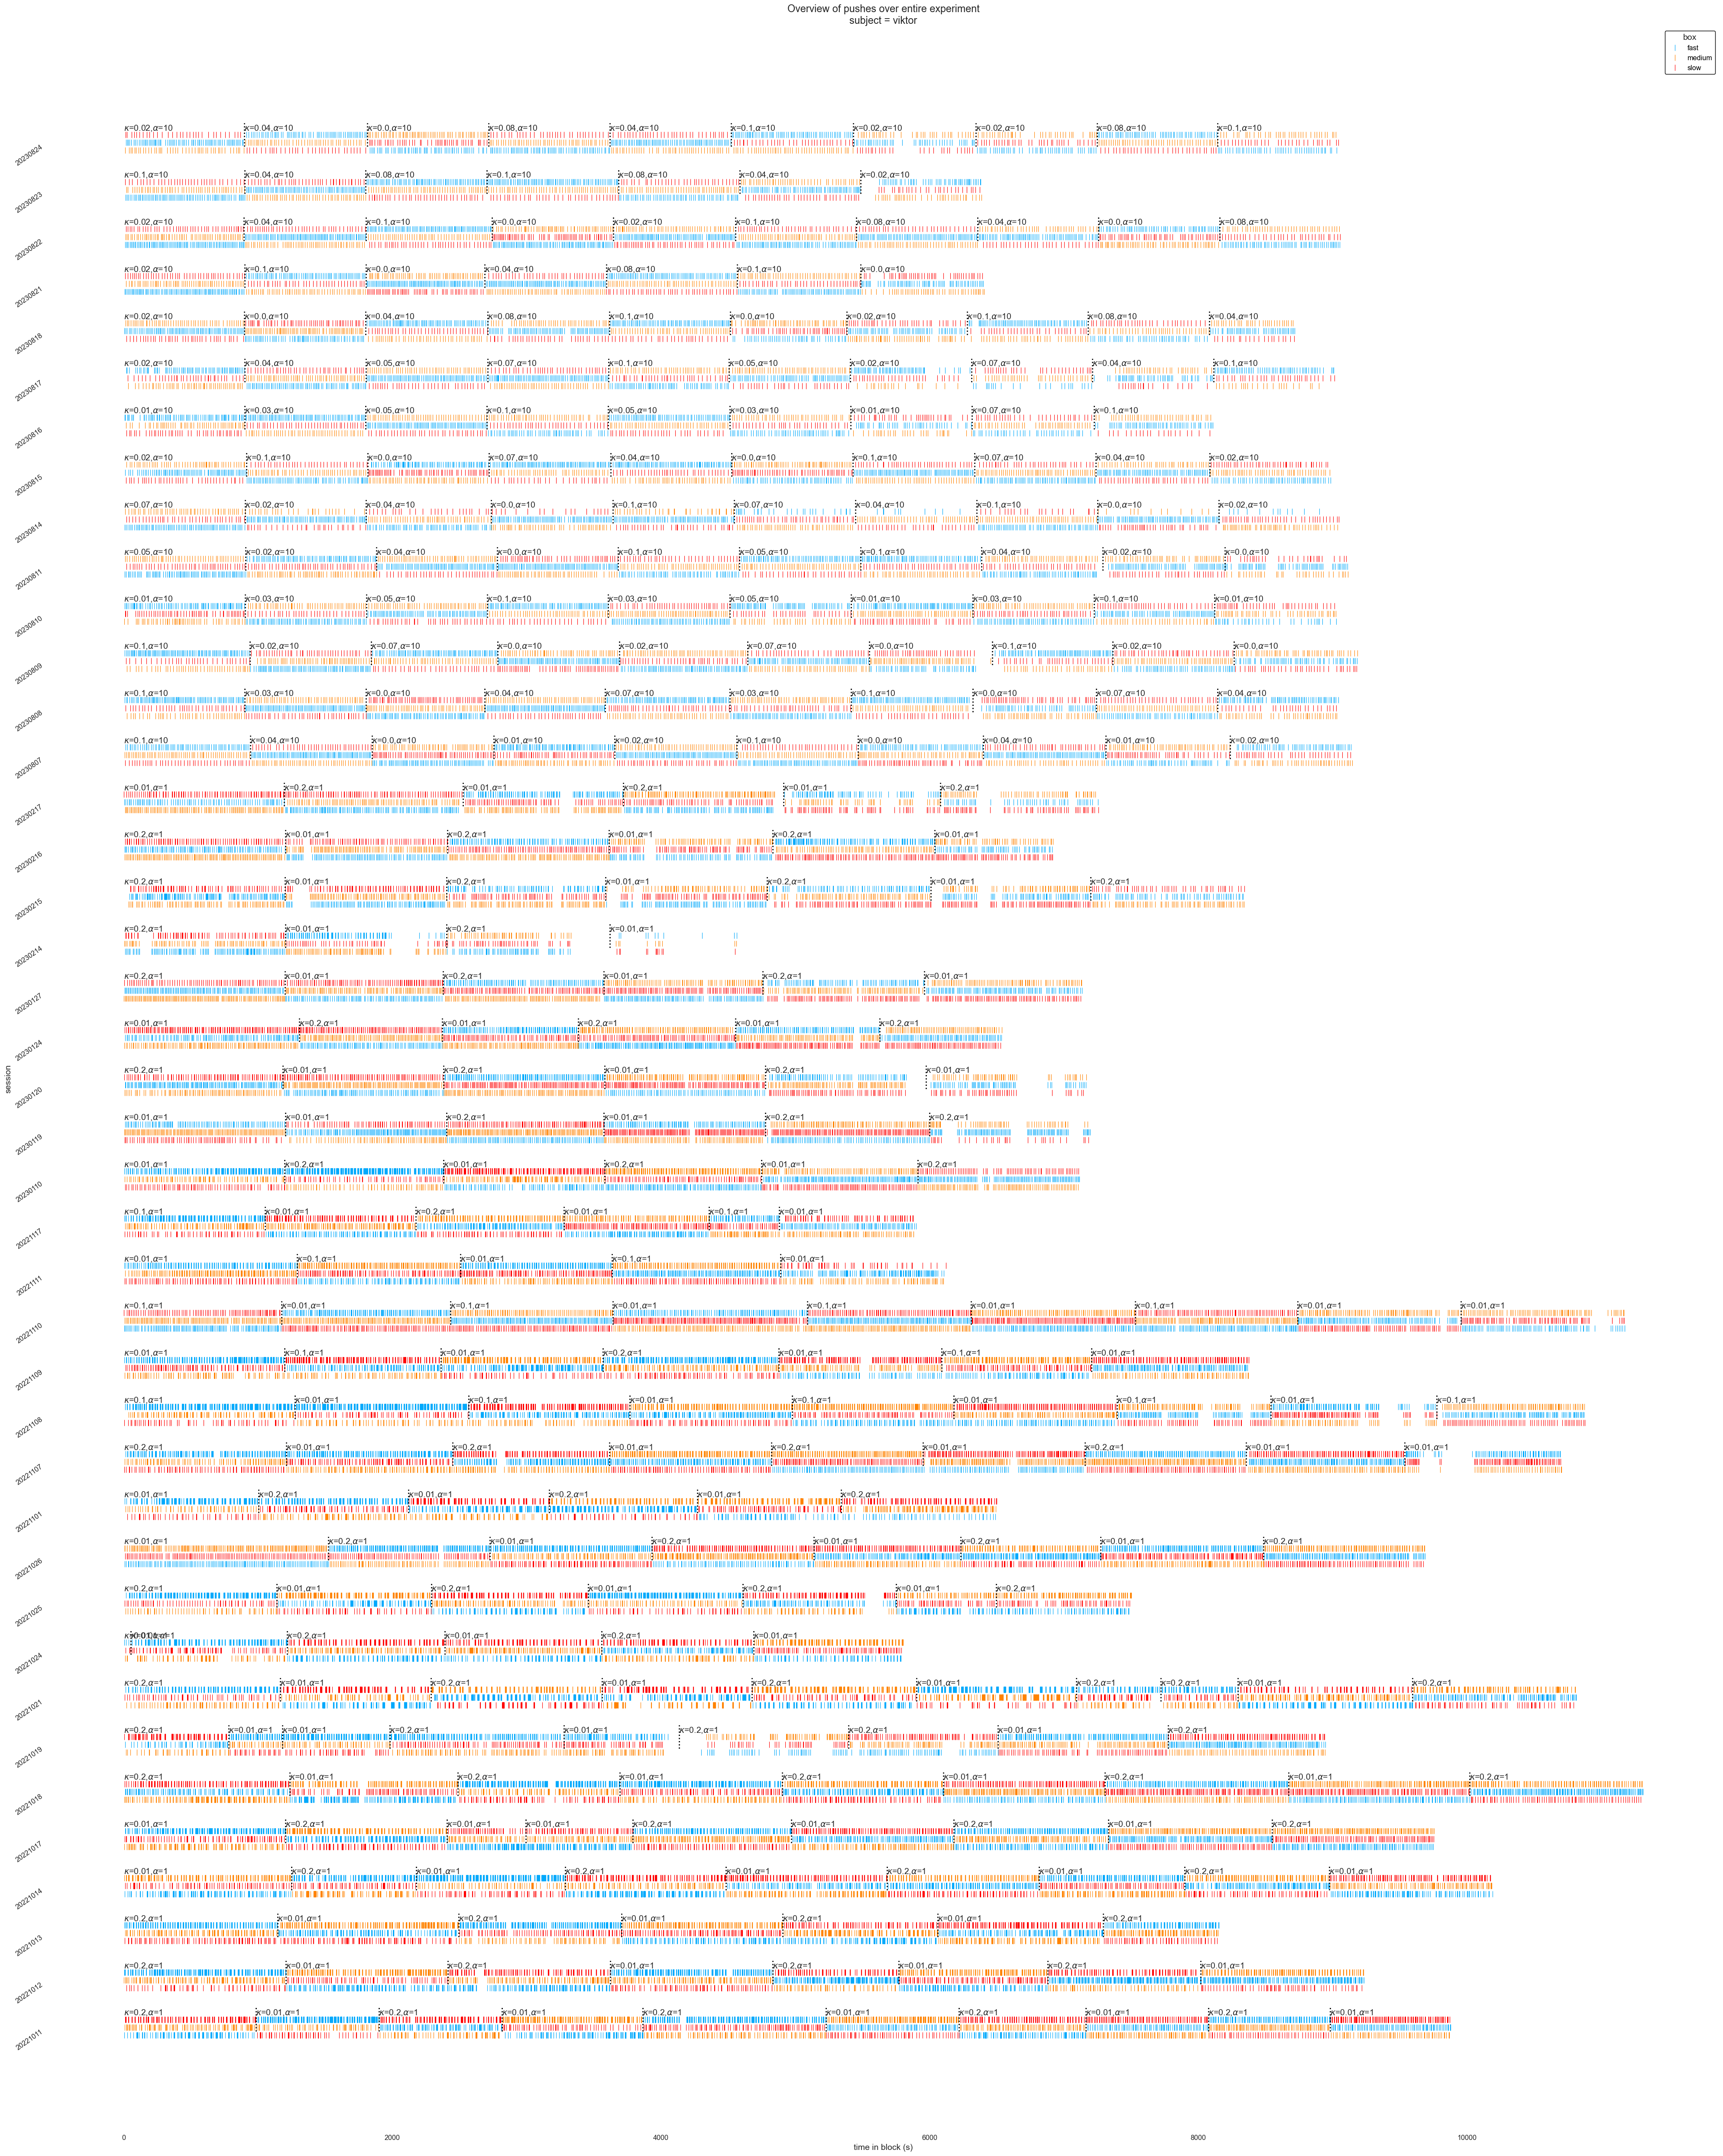

In [3]:
conds = dict(subject='viktor')
plot_experiment_overview(df, conds=conds, title_prefix='Overview of pushes over entire experiment', annotate_block=True,
                         fig_kwargs=dict(figsize=(40, 50)));

# Explore Data
The behavioral quantities we will explore are: consecutive push intervals, wait times, stay pushes, switch pushes, runlengths of consecutive choices, etc. These are defined as follows:
+ <span style='color:#03a9fc'>consecutive push intervals</span>: time between consecutive pushes.
+ <span style='color:#fa5cbe'>wait times</span>: time between consecutive pushes *at the same box*-- can include pushes made at other boxes during this interval. This is essentially how long the subject has been waiting on this box to be ready before they push.
+ <span style='color:#fa0c9f'>stay times</span>: the intersection of consecutive push intervals and wait times, which occurs when the subject chooses to stay at their current box and push again.
+ <span style='color:#22c793'>switch times</span>: the time between consecutive pushes at different boxes, which will largely capture travel time between equidistant boxes.
+ <span style='color:#ff9d00'>runlengths</span>: the number of times the subject pushes the same box before switching boxes.

One hypothesis we would like to test is whether the subjects' wait times obey the matching law, which is a normative theory of decision-making that posits that the optimal strategy is to allocate resources (time in our case) to each option proportionally to the reward rate achieved at that option. For example, a box with a faster mean schedule should be visited more frequently than a slower box. A good discussion of when matching is optimal can be found in [(Sakai & Fukai 2008)](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0003795). In our study, the matching law should materialize as the reward rates being proportional to the visit frequencies of each box; since each box has a different mean schedule, then, in expectation, the wait times for a given box should be proportional to the mean schedules of that box.

## Example Block

Here we show activity in an example block unfolding over time. Blue = fast box, yellow = medium box, red = slow box. Filled markers indicate rewarded pushes, unfilled unrewarded.

<Axes: title={'center': 'Pushes for \nsubject = viktor, session = 20230811, block = 3, kappa = 0.04, stim type = availability, shape = 10'}, xlabel='push times (s)'>

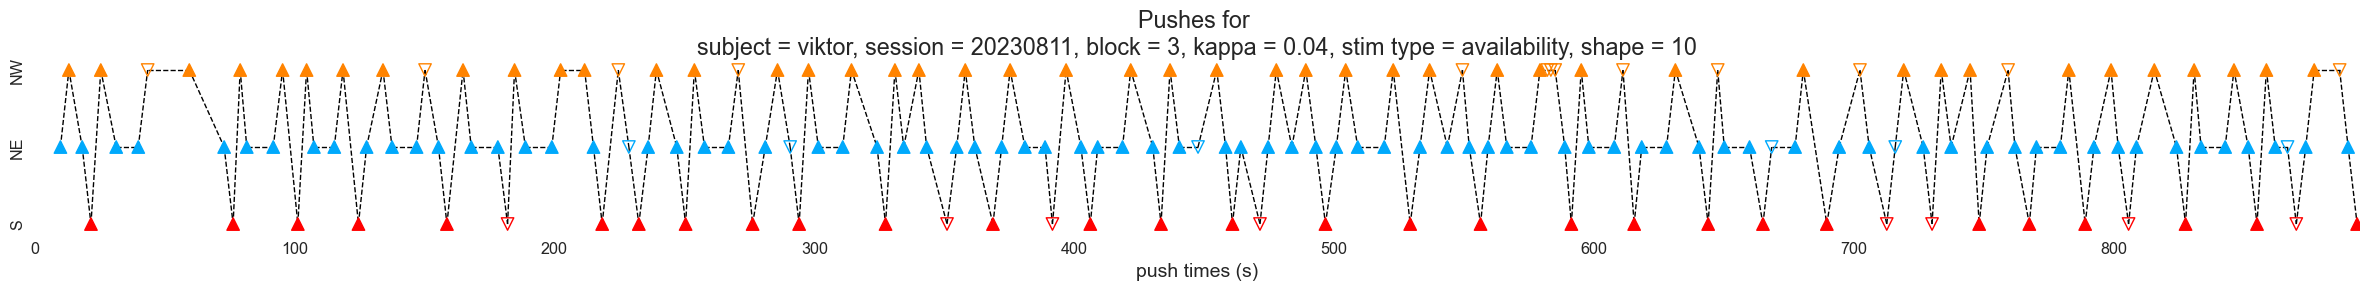

In [6]:
conds = dict(subject='viktor', session=20230811, block=3)
plot_pushes(df, conds, fig_kwargs=dict(figsize=(30,2.2)), legend = False)

## Pushes

Here is an overview of the statistics of the pushes for each subject.

<Axes: title={'center': 'Distribution of wait times at each box\n'}, xlabel='subject', ylabel='wait times (s)'>

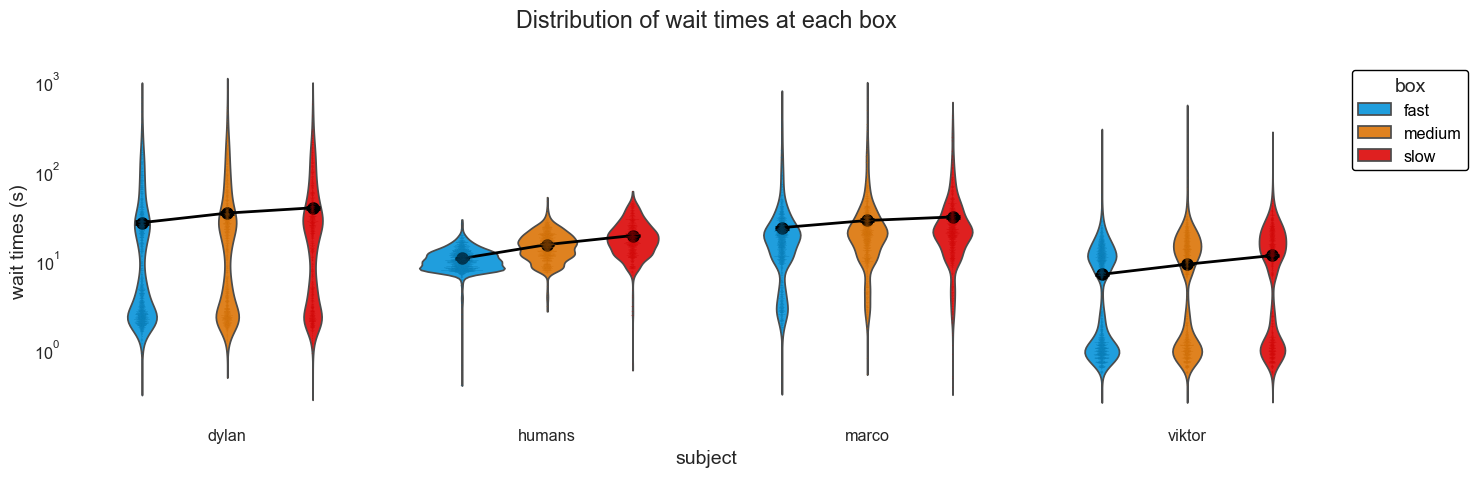

In [7]:
fig, ax = plt.subplots()
bp(sns.swarmplot)(df.groupby('subject').sample(10000, random_state=SEED, replace=True), x='subject',
                  y='wait times', hue='box', palette=PALETTE_DARK, legend=False, log_scale=True, size=0.25,
                  dodge=True, ax=ax)
bp(enhanced_violinplot)(df, x='subject', y='wait times', hue='box', palette=PALETTE,
                        title_prefix="Distribution of wait times at each box", y_unit='s', cut=0, inner=None,
                        log_scale=True, common_norm=True, ax=ax)

There is a bimodality present in a couple subjects. Below, we split the data into the exponential schedule and gamma schedule.

<Axes: title={'center': 'Distribution of wait times under exponential schedule\n'}, xlabel='subject', ylabel='wait times (s)'>

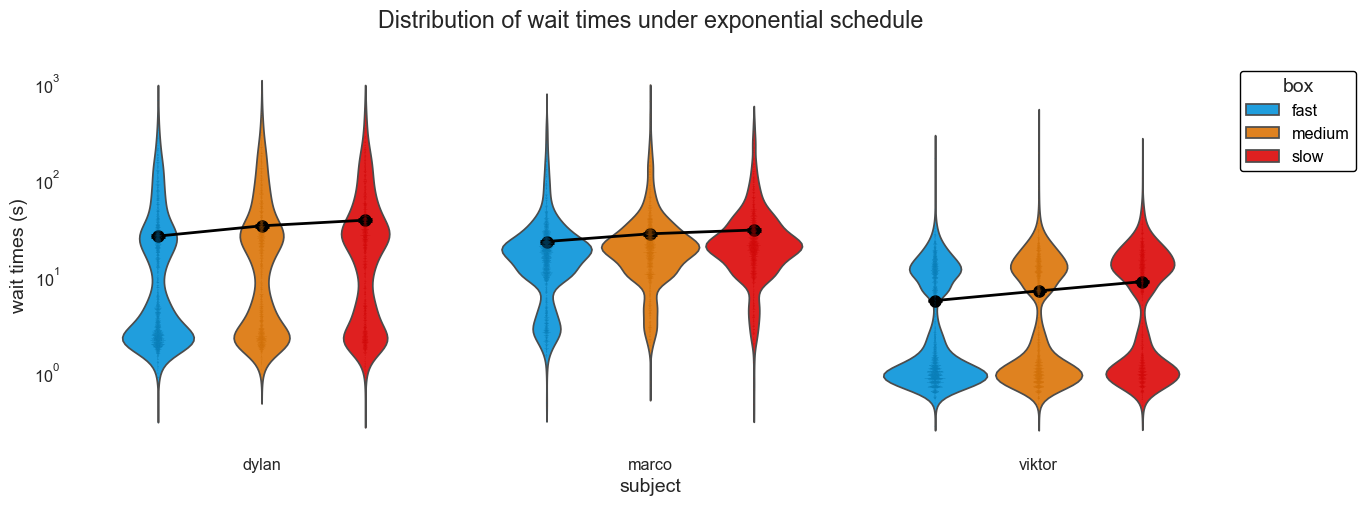

In [14]:
fig, ax = plt.subplots()
bp(sns.swarmplot)(df.xs(1, level = 'shape').groupby('subject').sample(10000, random_state=SEED, replace=True), x='subject',
                  y='wait times', hue='box', palette=PALETTE_DARK, legend=False, log_scale=True, size=0.25,
                  dodge=True, ax=ax)
bp(enhanced_violinplot)(df.xs(1, level = 'shape'), x='subject', y='wait times', hue='box', palette=PALETTE,
                        title_prefix="Distribution of wait times under exponential schedule", y_unit='s', cut=0, inner=None,
                        log_scale=True, common_norm=True, ax=ax)

<Axes: title={'center': 'Distribution of wait times under gamma schedule\n'}, xlabel='subject', ylabel='wait times (s)'>

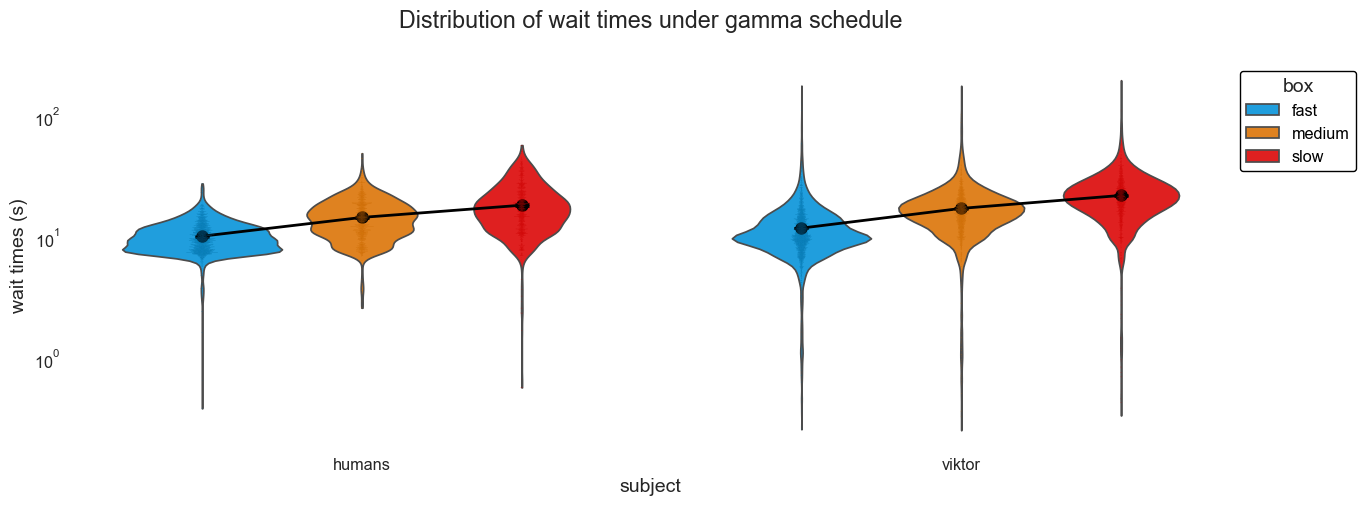

In [15]:
fig, ax = plt.subplots()
bp(sns.swarmplot)(df.xs(10, level = 'shape').groupby('subject').sample(10000, random_state=SEED, replace=True), x='subject',
                  y='wait times', hue='box', palette=PALETTE_DARK, legend=False, log_scale=True, size=0.25,
                  dodge=True, ax=ax)
bp(enhanced_violinplot)(df.xs(10, level = 'shape'), x='subject', y='wait times', hue='box', palette=PALETTE,
                        title_prefix="Distribution of wait times under gamma schedule", y_unit='s', cut=0, inner=None,
                        log_scale=True, common_norm=True, ax=ax)

It's clear the bimodality results from some property of the exponential schedule. To confirm this and see if there are any other trends that emerge throughout the experiment, we'll next show the distribution of push intervals in each session. Since humans do not have session data, they are omitted for now.

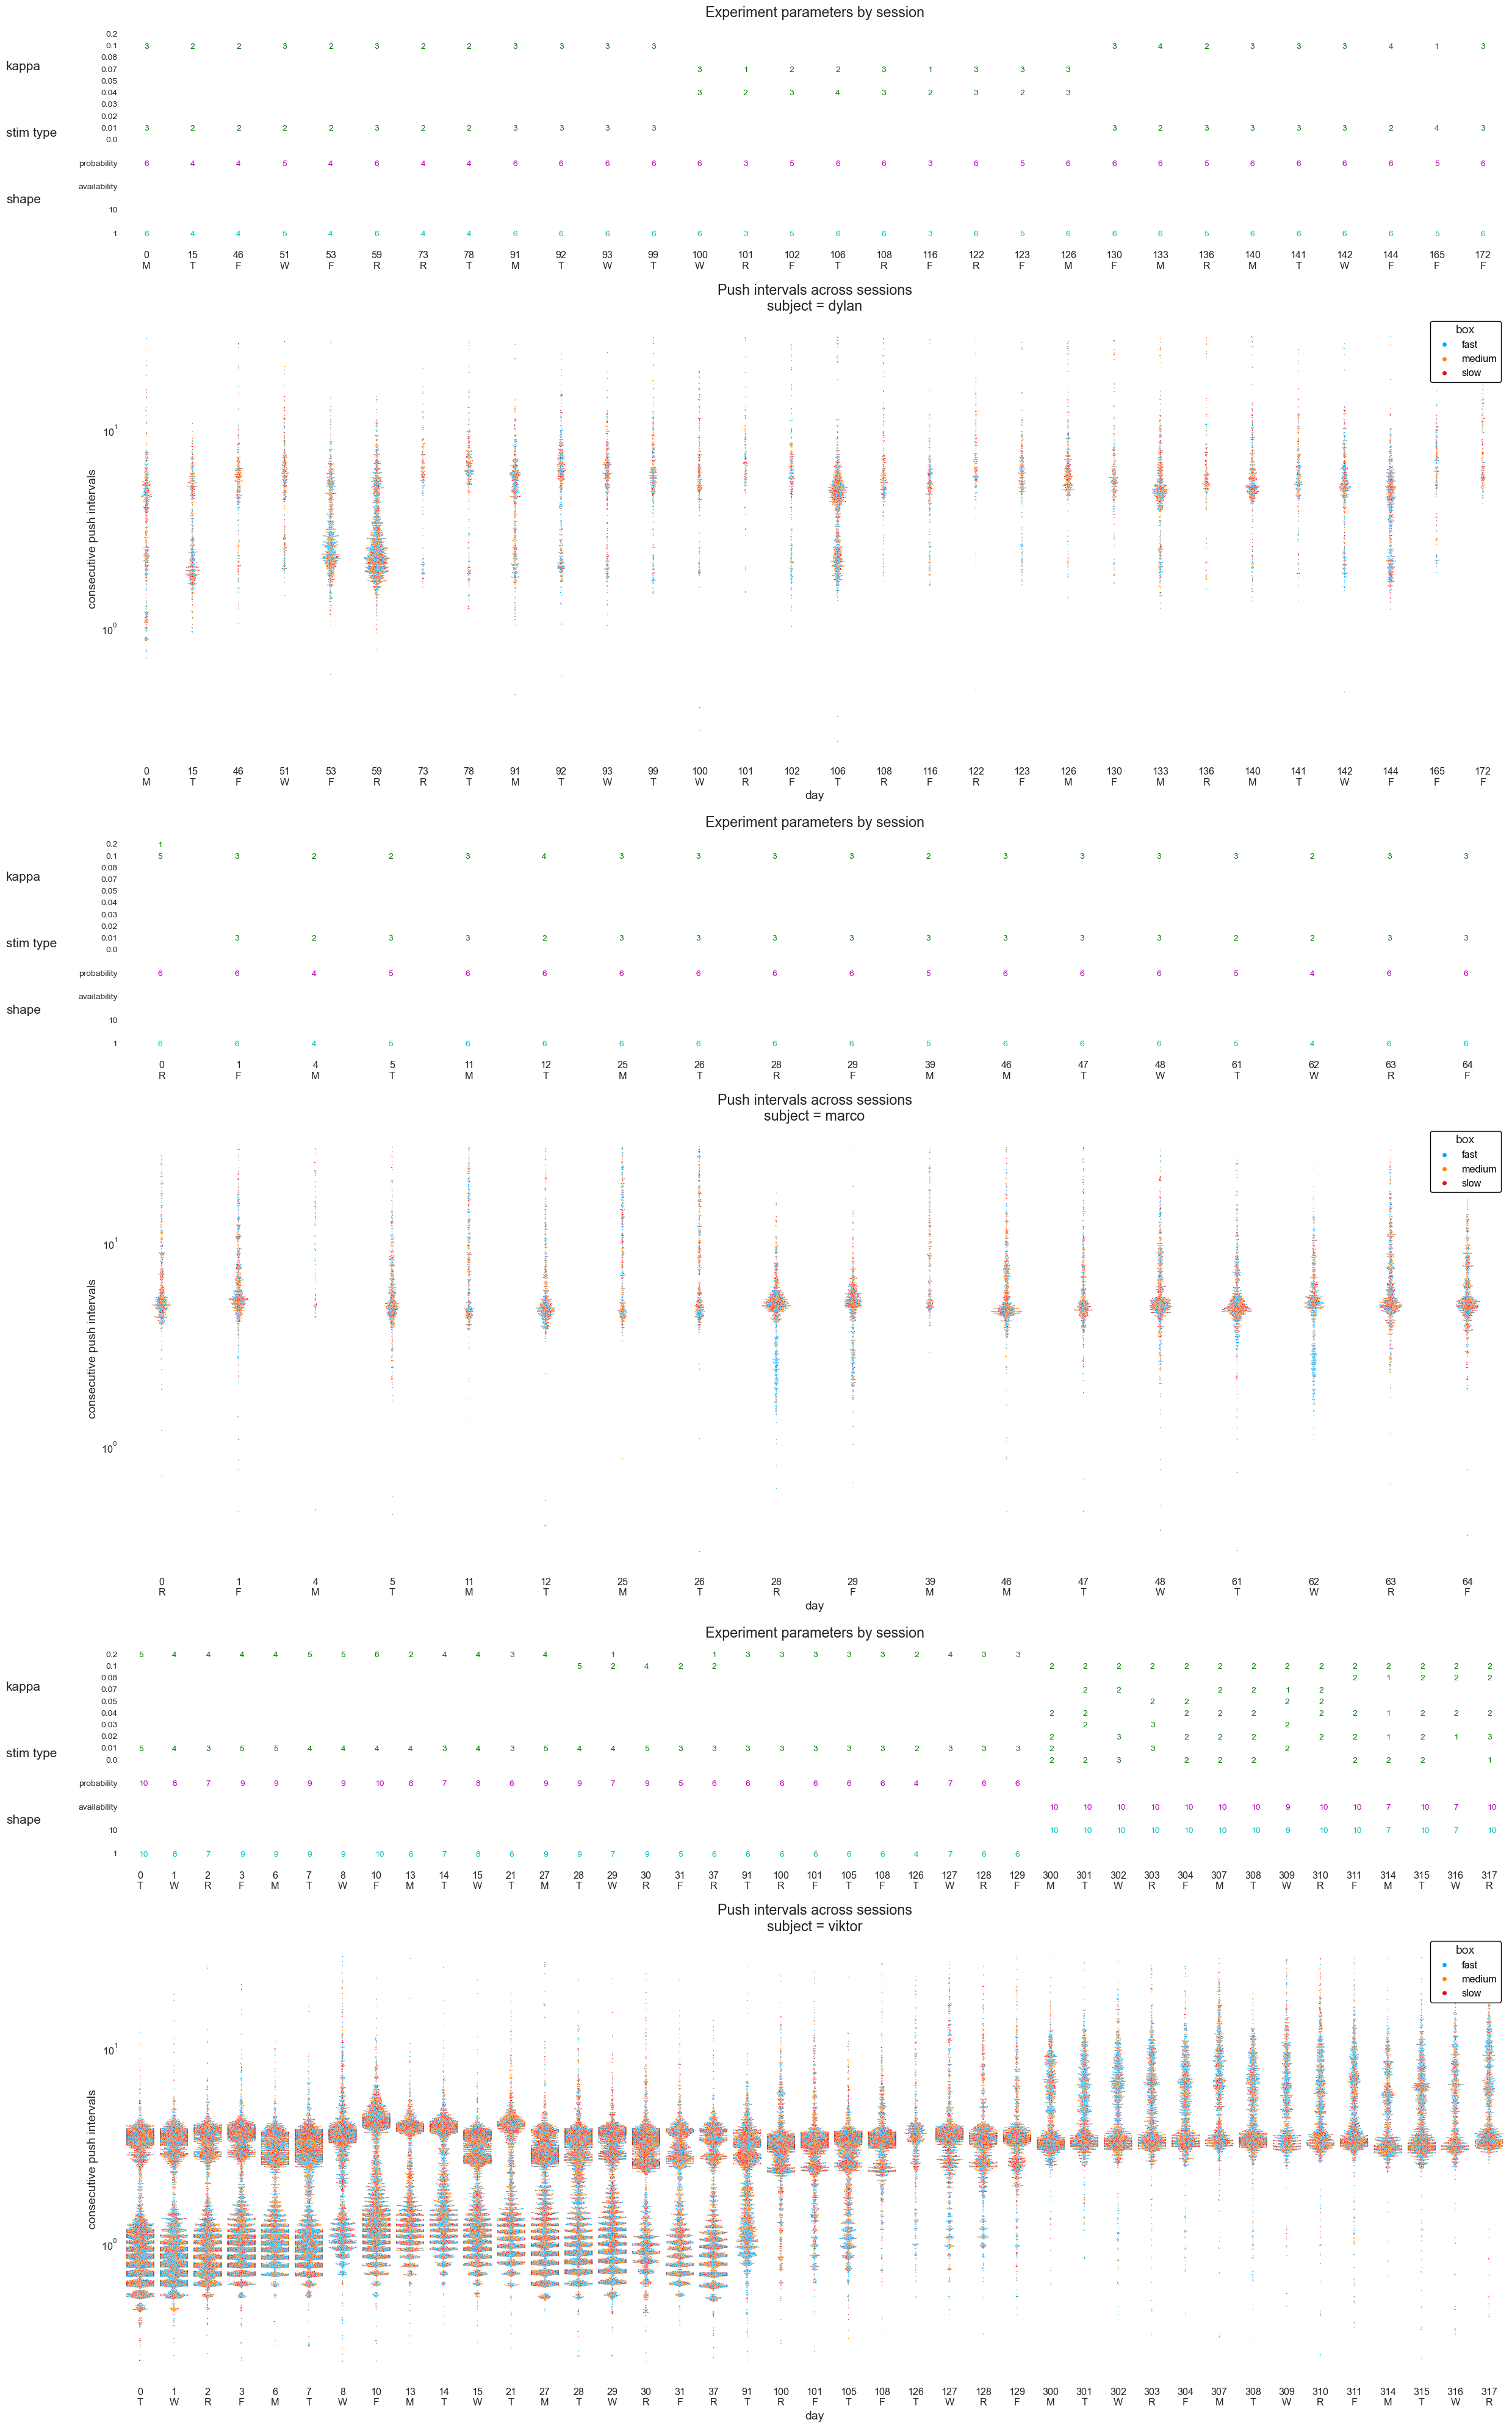

In [33]:
%%capture --no-display
# Examine monkeys separately from humans
monkey_subjects = ['dylan', 'marco', 'viktor']
conds = {'subject': monkey_subjects}
df_monkey = filter_df(df, conds).copy()

# Reformat time data
df_monkey['session id'] = pd.to_datetime(df_monkey.index.get_level_values('session'), format='%Y%m%d')
df_ref = df_monkey.groupby('subject')['session id'].min()
df_monkey = df_monkey.join(df_ref, how='left', rsuffix='_ref', on=['subject'])
df_monkey['day'] = (df_monkey['session id'] - df_monkey['session id_ref']).dt.days
fig, axes = plt.subplots(len(monkey_subjects) * 2, 1, figsize=(25, 40), height_ratios=[1, 2] * len(monkey_subjects))
for i, subj in enumerate(monkey_subjects):
    plot_experiment_parameters(df_monkey, conds={'subject': subj}, ax=axes[2 * i], label_rotation=0)
    bp(sns.swarmplot)(df_monkey, x="day", y="consecutive push intervals", conds={'subject': subj}, hue = 'box', palette = PALETTE,
                      title_prefix="Push intervals across sessions", size=1, log_scale=True,
                      legend_kwargs={'markerscale': 5}, ax=axes[2 * i + 1])

    # Add weekday labels
    labels = axes[2 * i + 1].get_xticklabels()
    days = df_monkey.xs(subj, level='subject').reset_index().groupby(['session'], as_index=False)['week day'].max()[
        'week day']
    for j, l in enumerate(labels):
        tmp = l.get_text()
        labels[j] = tmp + '\n' + days[j]
    axes[2 * i + 1].set_xticklabels(labels)

    # Align x-axis
    axes[2 * i].sharex(axes[2 * i + 1])
fig.tight_layout()

These swarmplots are useful for visualizing individual data points by jittering the ones that collide, to the limit that the data points aren't too cluttered and impede comprehension. The x-axis denotes days since the first session (with day 0 corresponding to the first session) and the y-axis are the log push intervals in each session. For Dylan and Marco, the number of data points is manageable but for Viktor they are so numerous that you can see where the plot struggles to fit all the data points. Each swarmplot is preceded by an experiment overview where for each session we denote how many blocks had a certain parameter value, which gives us a sense of the timeline for how the experiment evolved and when decisions were made to change the experiment. The x-axes for a swarmplot and its corresponding experiment overview are aligned for ease of comparison.

One thing to look for are sessions that look distributionally different from the others, e.g. day 0 for Dylan shows a bump around extremely fast push intervals around 1 second, and days 53-59 contain a big bump of pushes right above 1 second. For Marco, day 4 is extremely scarce in pushes compared to other days. It's interesting to see heterogeneous patterns in the pushes, in particular for Viktor. In fact, we see three distinct patterns of clusters organized in time: days 0-91 exhibit strong bimodality, days 100-129 are more unimodal and concentrate towards larger push intervals, and days 300-317 concentrate on even larger push intervals. Notice that day 300 coincides with a change in the experiment from the exponential schedule to gamma schedule.

Since the exponential schedule depicts atypical behavior, this notebook will be dedicated to the gamma schedule and a supplementary notebook will focus on the exponential schedule.

In [16]:
df = df.xs(10, level = 'shape', drop_level = False)

Here are the distributions of wait times at each box as a function of stimulus reliability.

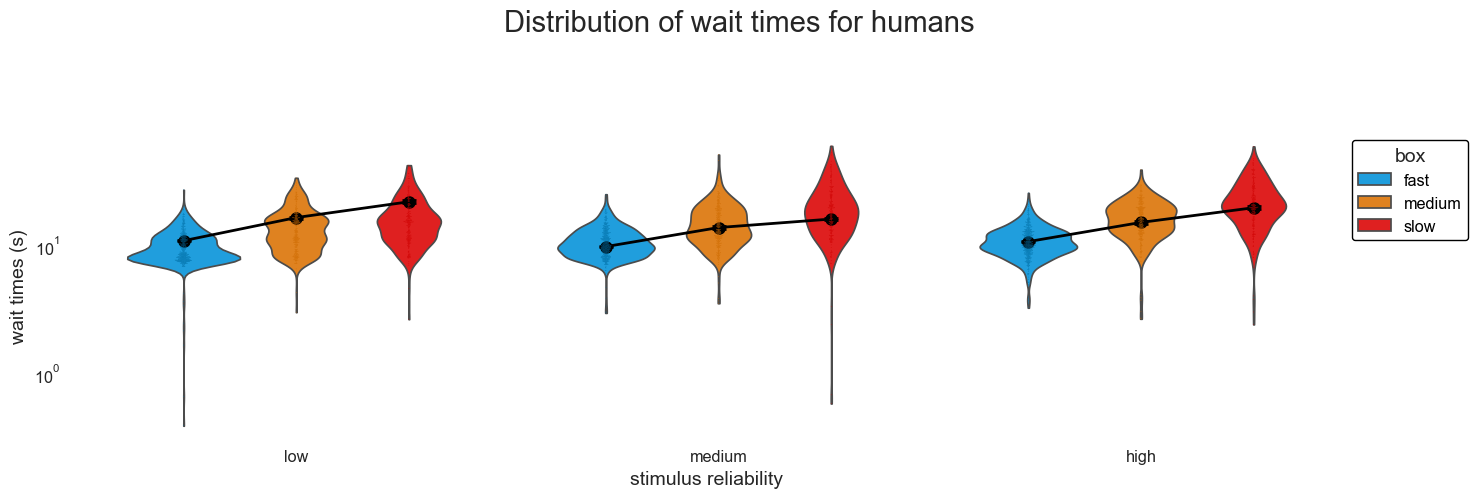

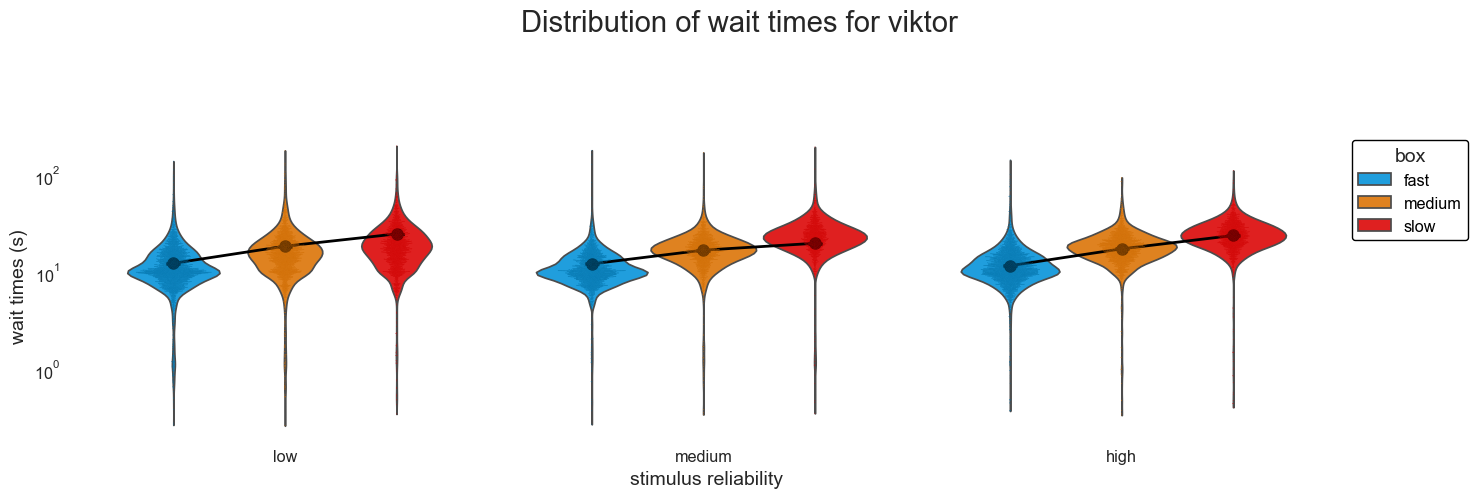

In [17]:
subjects = df.index.unique('subject')
for subject in subjects:
    plot_wait_times(df.xs(subject, level = 'subject'), title = f'Distribution of wait times for {subject}')

The distributions are very similar across stimulus reliabilities, suggesting subjects are able to differentiate the boxes to a similar degree regardless of task difficulty. The distributions seem to grow slightly sharper as reliability increases.

Next, we show the distribution of consecutive push intervals between all pairs of boxes simultaneously, similar to a transition matrix where the rows are the boxes the subject first pushes and the columns are where they push next.

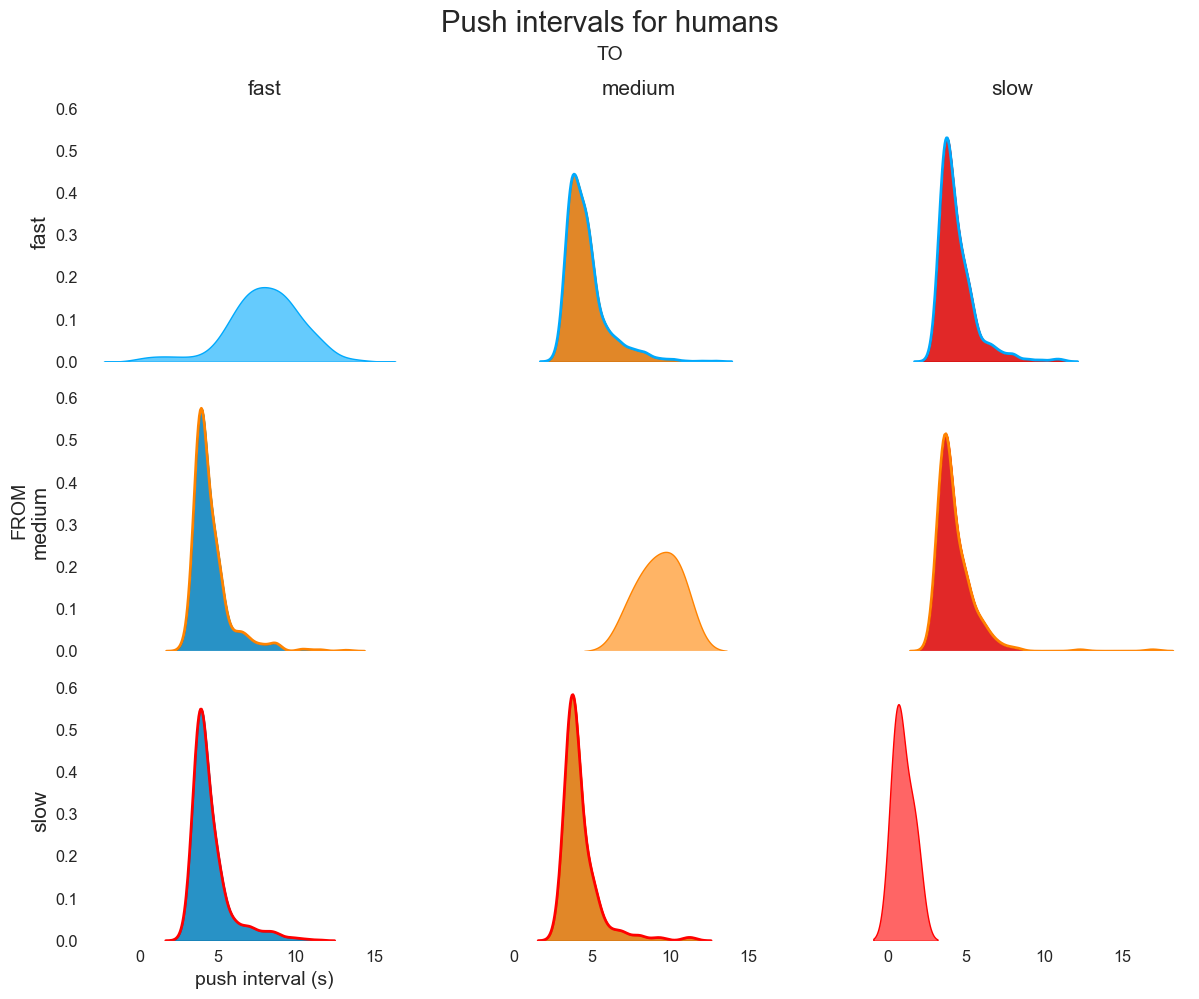

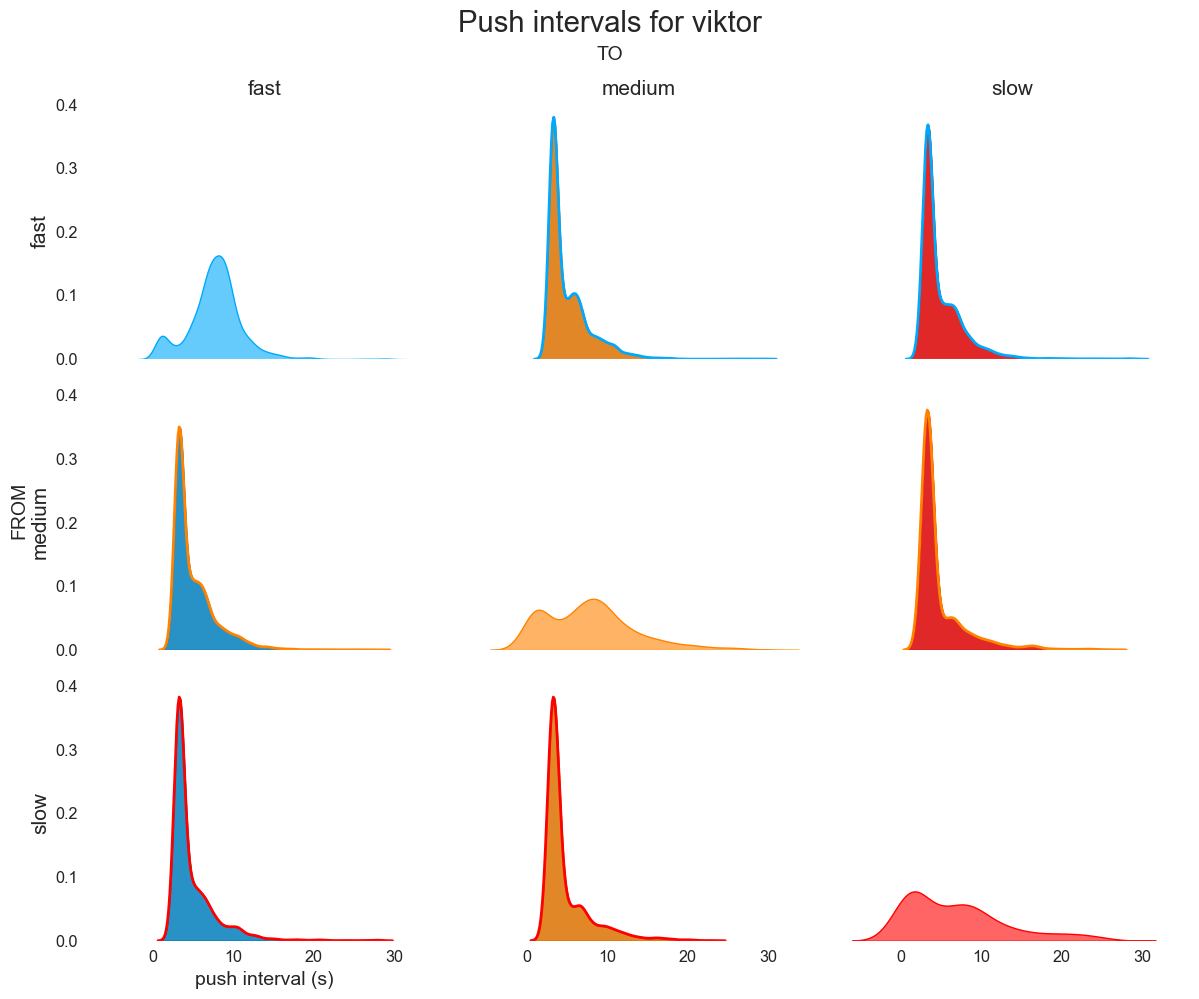

In [18]:
for subject in subjects:
    plot_stay_switch_pushes(df.xs(subject, level = 'subject'), title = f"Push intervals for {subject}")

First, the switch times are qualitatively similar across all pairs of boxes. Second, the stay times across all boxes share bimodal features covering about the same range, but the fast box looks qualitatively different from the other boxes.

Finally, the distribution of consecutive push intervals can reveal the complexity of the decision process-- for example, suppose the decision space is {push at box$_i$, wait}, and each timestep the animal makes a decision whether and where to push. Then, ignoring travel cost, a simple Hidden Markov Model (HMM) of this decision process would result in geometrically distributed intervals between pushes. Fitting an exponential distribution to each empirical distribution via maximum likelihood estimation and then performing a Kolmogorov-Smirnoff test under the null hypothesis that the data is drawn from the fitted exponential distributions resulted in rejecting the null hypothesis in each case, so the push intervals are likely the result of a much more complicated decision process.


### Runlengths
To get a sense of the statistics of *sequences* of pushes, we can gather the runlengths, that is the number of consecutive pushes at the same box before the subject switches.

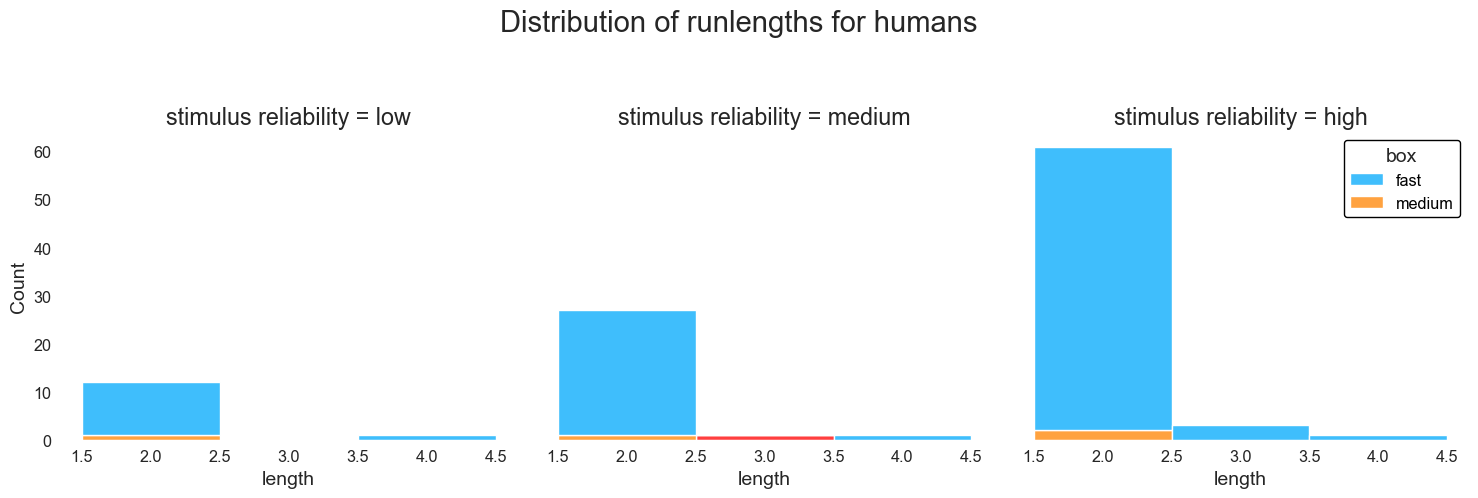

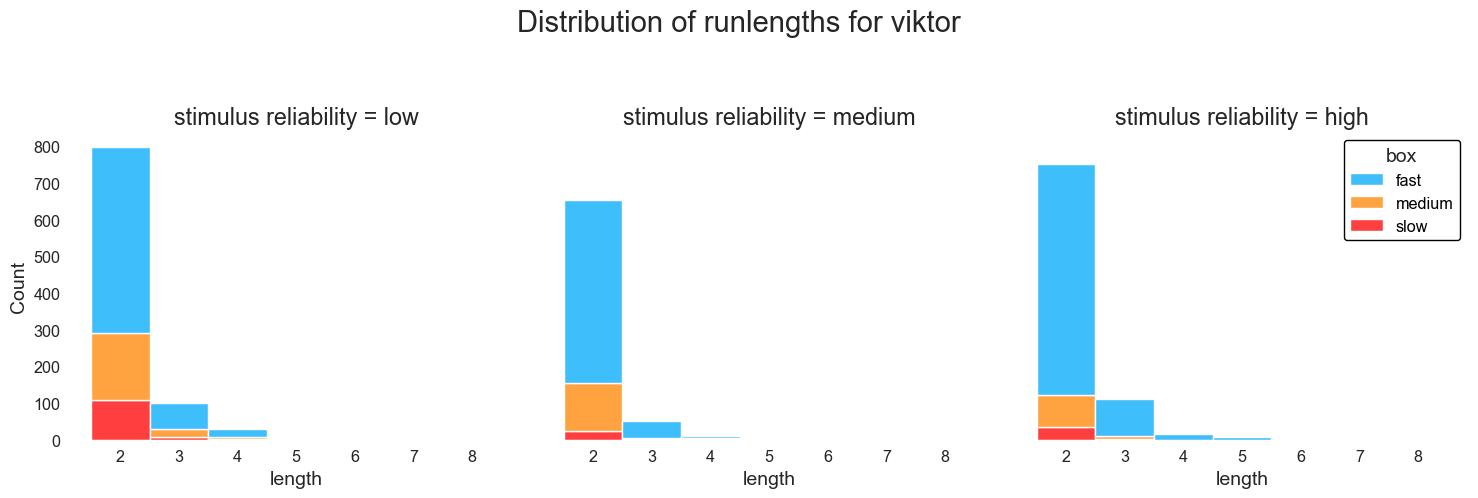

In [20]:
# Categorize stimulus reliabilities
kappas = {
    'humans': dict(zip(KAPPA_LEVELS, [(0.0, 0.02), (0.03, 0.04, 0.06), (0.07, 0.08, 0.1)])),
    'viktor': dict(zip(KAPPA_LEVELS, [(0.0, 0.01, 0.02), (0.03, 0.04, 0.05), (0.07, 0.08, 0.1)]))
}

if not 'stimulus reliability' in df.index.names:
    for subject, kappa_filter in kappas.items():
        for label, values in kappa_filter.items():
            df_filter = filter_df(df, {'subject': subject, 'kappa': values})
            df.loc[df_filter.index, 'stimulus reliability'] = label
    df.set_index('stimulus reliability', append = True, inplace = True)

# Plot runlengths
for subject in subjects:
    plot_runlengths(filter_df(df, {'subject': subject}), title = f'Distribution of runlengths for {subject}')

Aside from fitting in slightly more pushes at the fast box when the reliability is high, there isn't much difference in runlengths between reliabilities.

### Push Intervals vs Reward Intervals

Here, we show each wait time along with the reward interval of the box that was pushed. Basically, we want to see how well the subjects timed their pushes to the reward interval of the box. Our expectation is that as the stimulus reliability increases, the subjects should be able to time their pushes more reliably to occur after the reward interval.

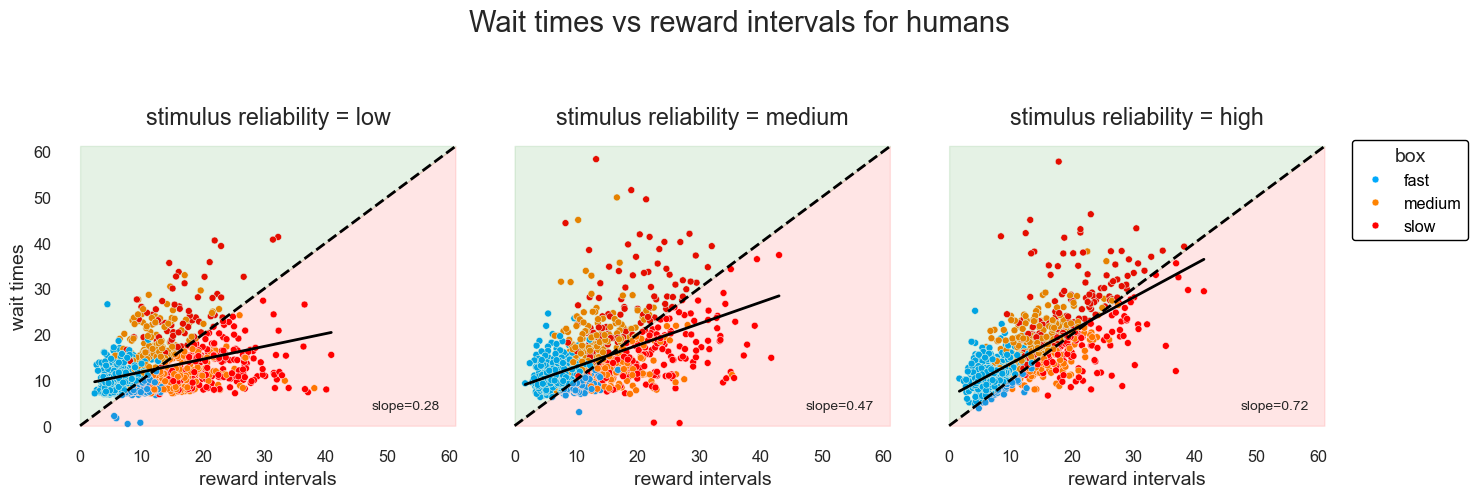

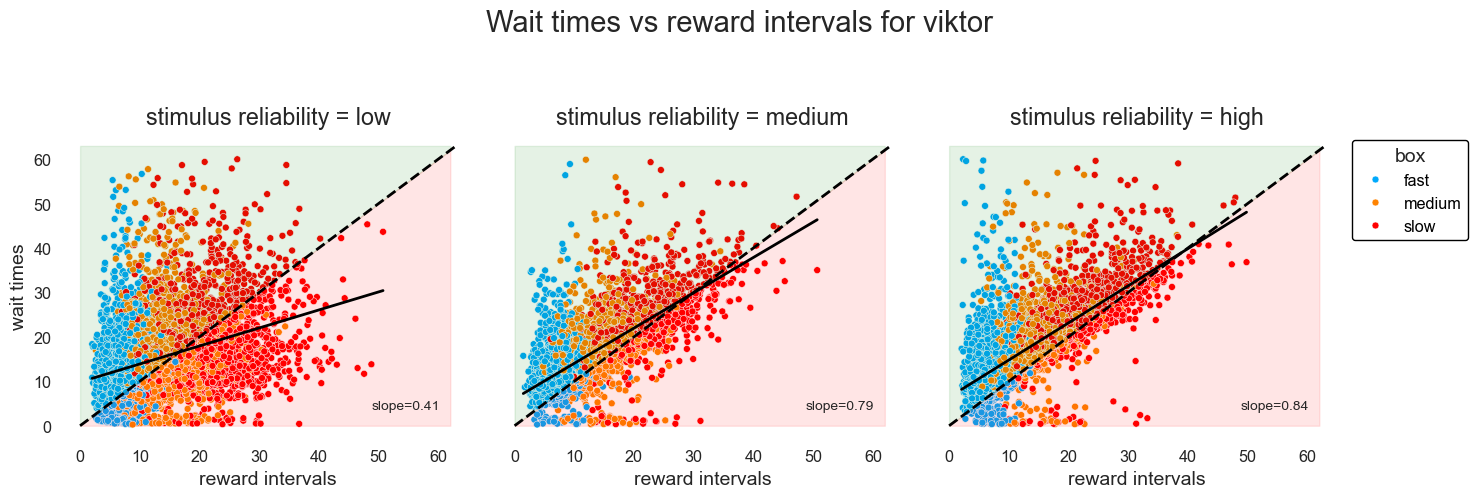

In [21]:
for subject in subjects:
    plot_push_intervals_vs_reward_intervals(filter_df(df[(df['wait times'] < 60) & (df['reward intervals'] < 60)], {'subject': subject}), title = f'Wait times vs reward intervals for {subject}', annotate_reg=True)

As expected, the correlation and slope between the wait times and reward intervals increases with stimulus reliability.

### Surprise

We can ask how much the factor of "surprise" at a particular reward outcome influences future behavior. For example, if the subject waits a long time and still doesn't get reward, they might 1) switch boxes and 2) wait longer to push the box they left if they start to believe it's a slower box. Formally, this change in belief can be captured by the Fisher information, which we will show in a later section.

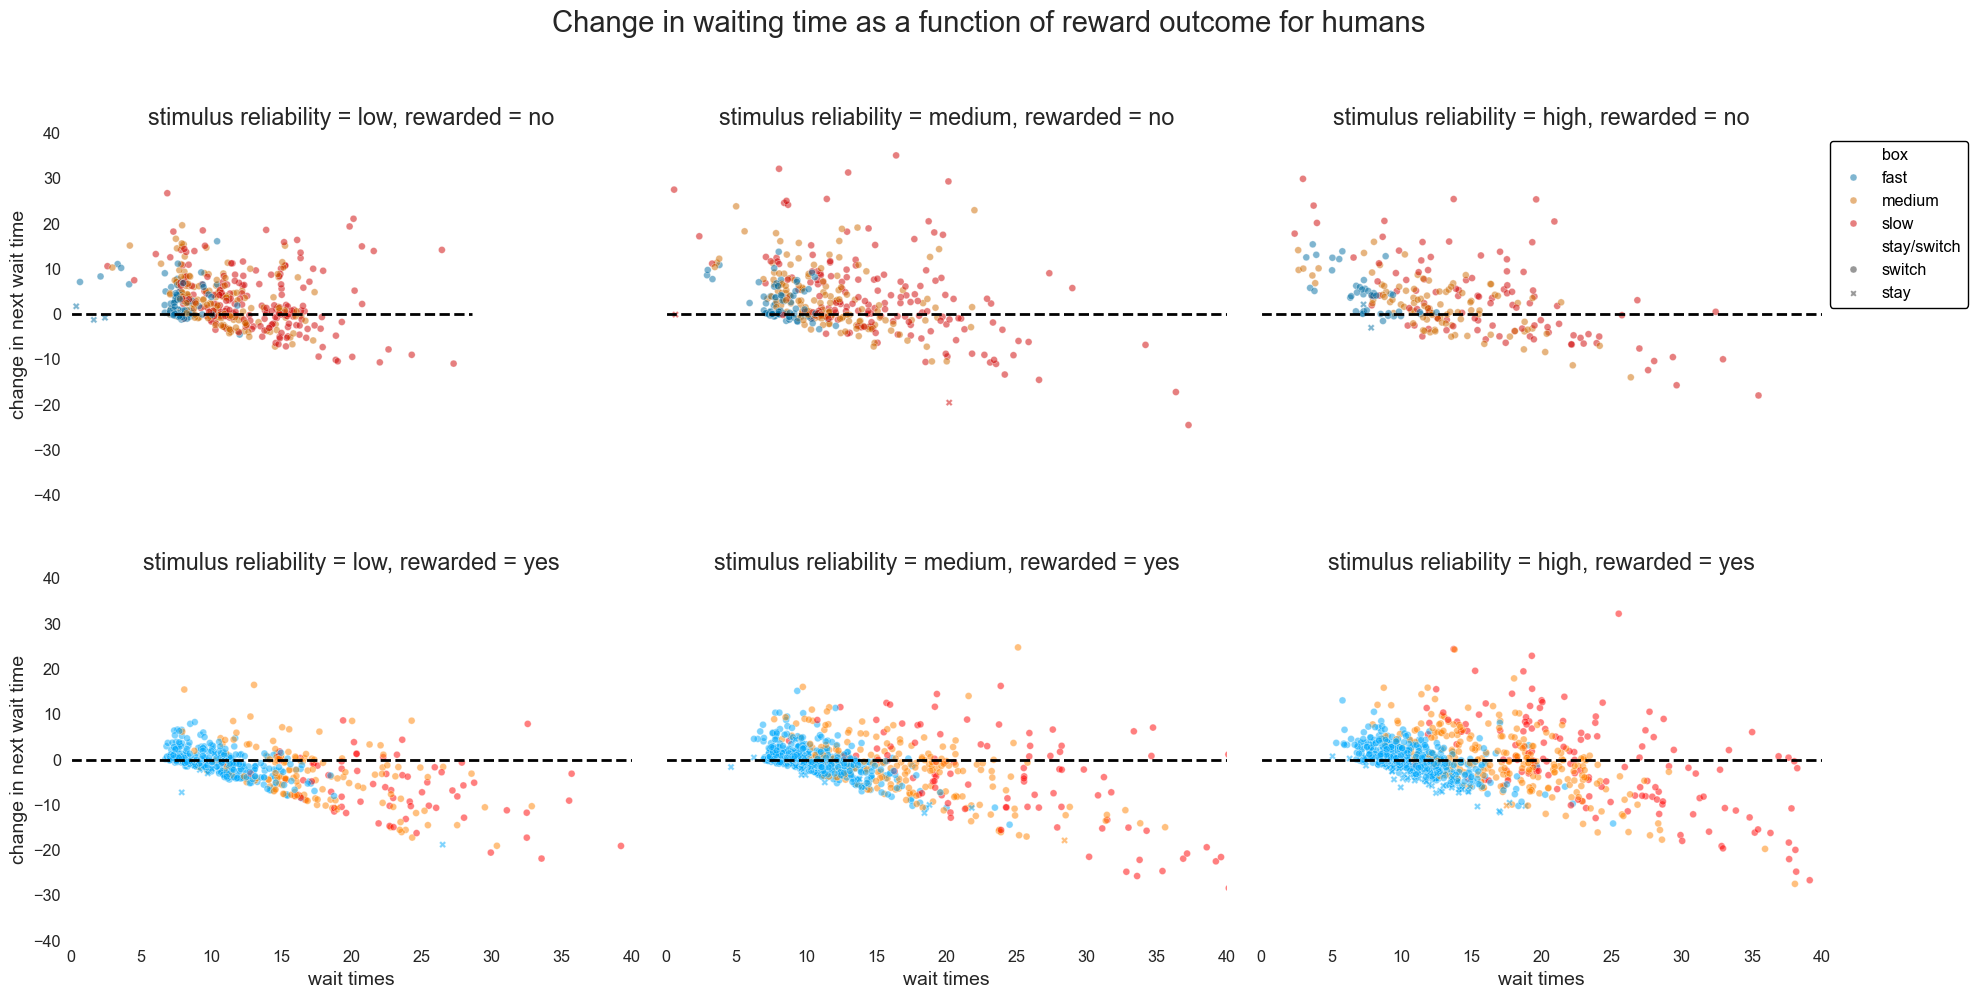

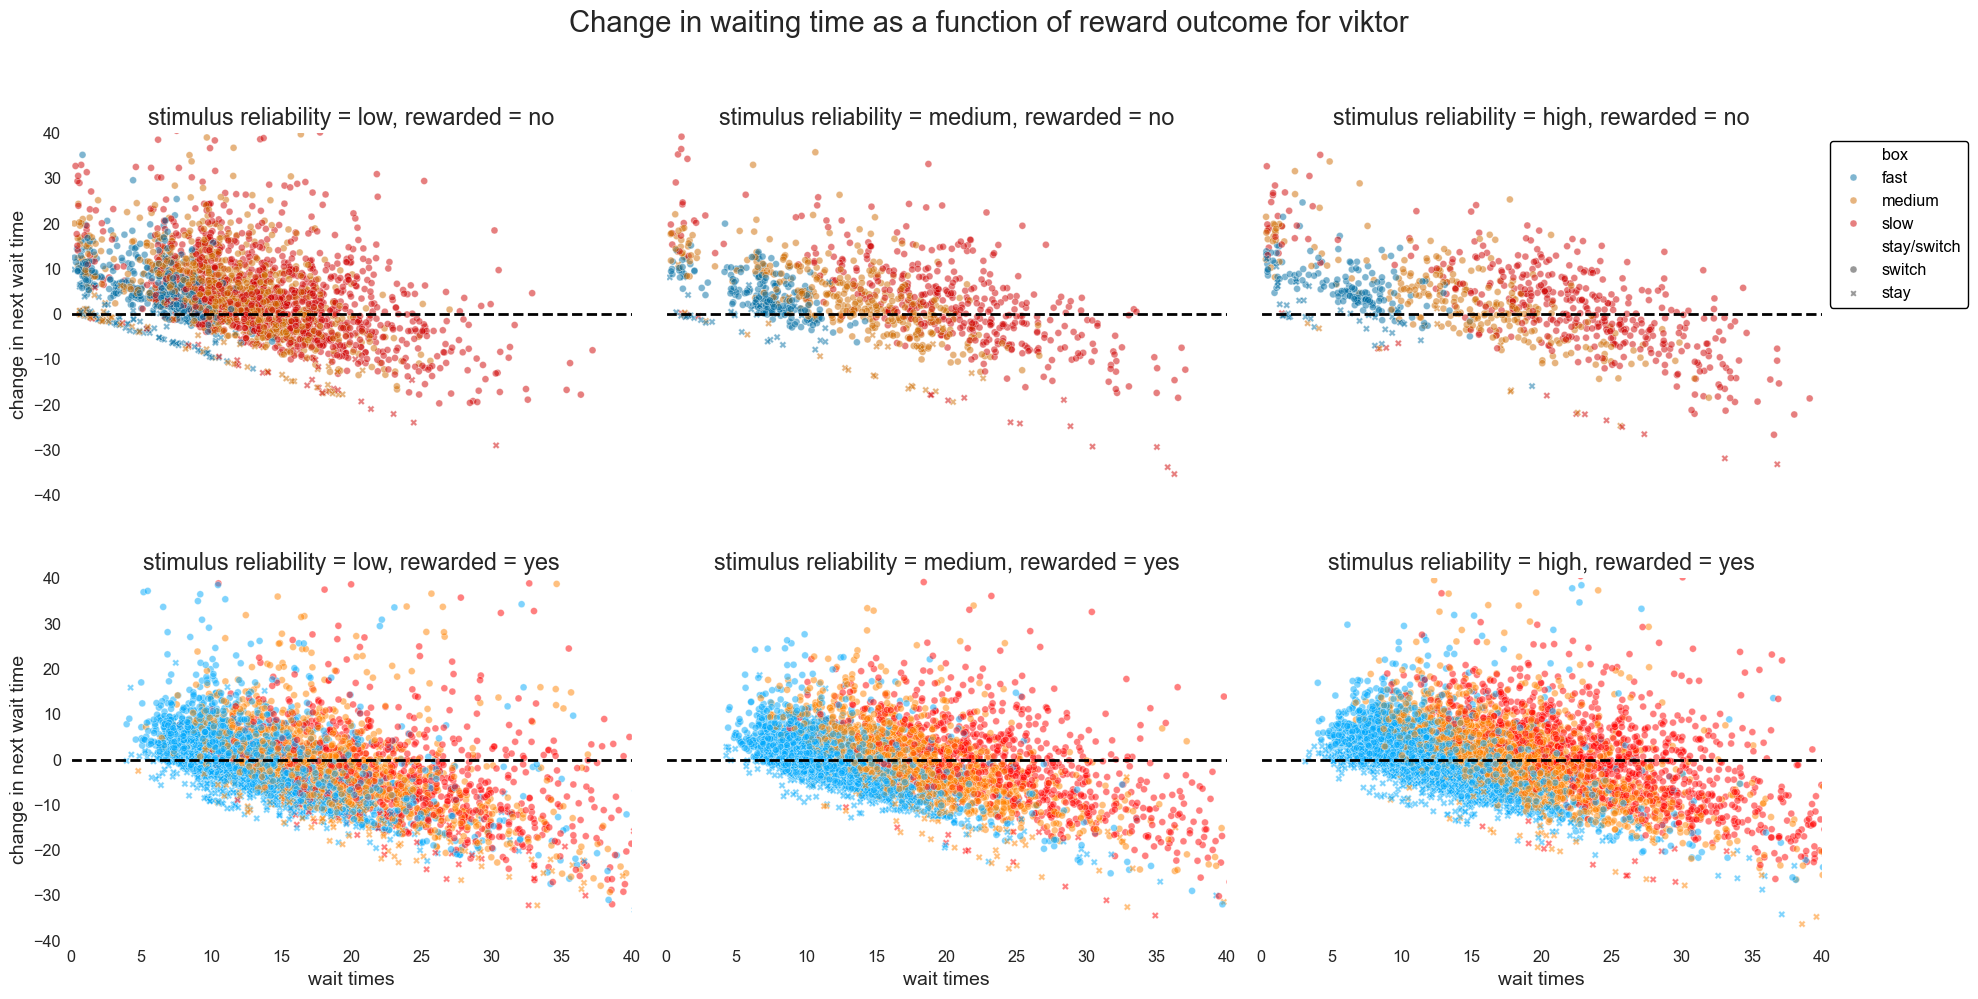

In [22]:
%%capture --no-display
for subject in subjects:
    plot_next_push_surprise(filter_df(df, conds = {'subject': subject}), fig_kwargs = dict(figsize = (20, 10)), title = f'Change in waiting time as a function of reward outcome for {subject}',legend_kwargs = dict(loc="upper left", bbox_to_anchor = (1,1), title = None))

Across both rewarded and unrewarded cases, there is a transition point at 20-25 s between waiting longer and going sooner the next push that is roughly preserved across all conditions. As reliability increases, the wait time on the x-axis clusters by boxes better and better. There is a distinct string of stay pushes that occur near the bottom of the graph where the subject pushes a few seconds after the current push. Visually, it appears that the subject switches a lot more across both reward outcomes, but when choosing to stay and push again, does so more after being rewarded. We confirm this below by counting how many times they stay or switch depending on how long they waited.

### Probability of staying at same box

Here we calculate the probability of staying as a function of waiting time. We do this separately for the rewarded and unrewarded case.

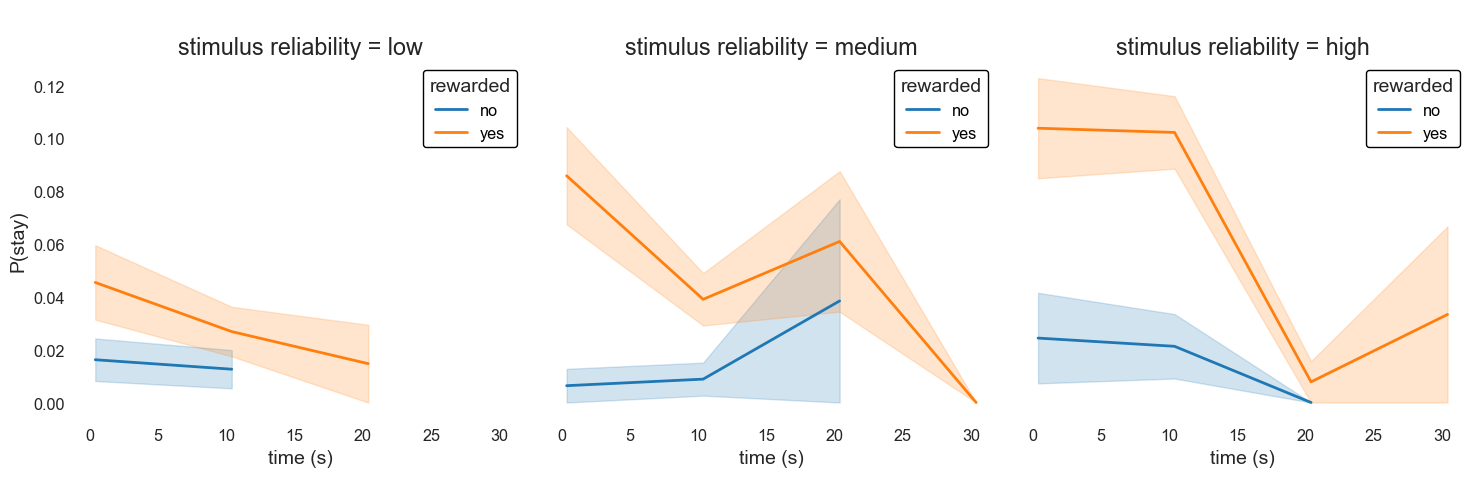

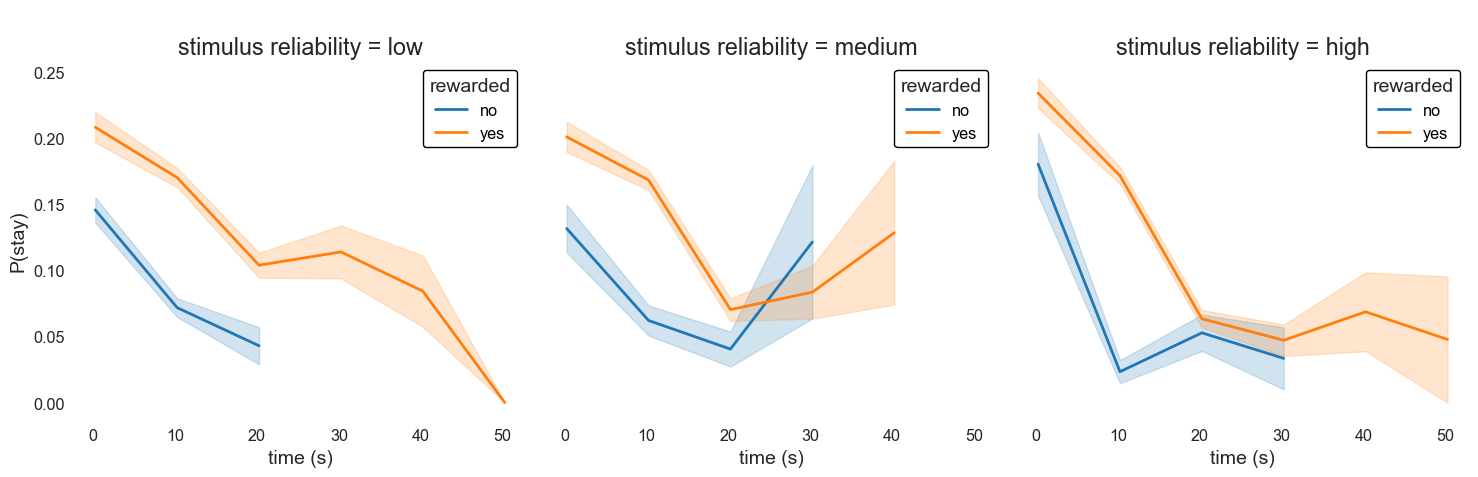

In [275]:
%%capture --no-display
for subject in subjects:
    ax = plot_stay_probabilities(filter_df(df, conds = {'subject': subject}), title = f'Probability of staying at same box as a function of reward outcome for {subject}', min_obs = 20)

Clearly, the probability of staying is greater after receiving reward, but it generally goes down the longer the subject waits, with the exception of some weird quirks that could be due to low data volume.

## Block Dynamics

In this section, we explore how behavioral variables, such as reward rate and push frequency, evolve over time in the block.

### Reward Rate

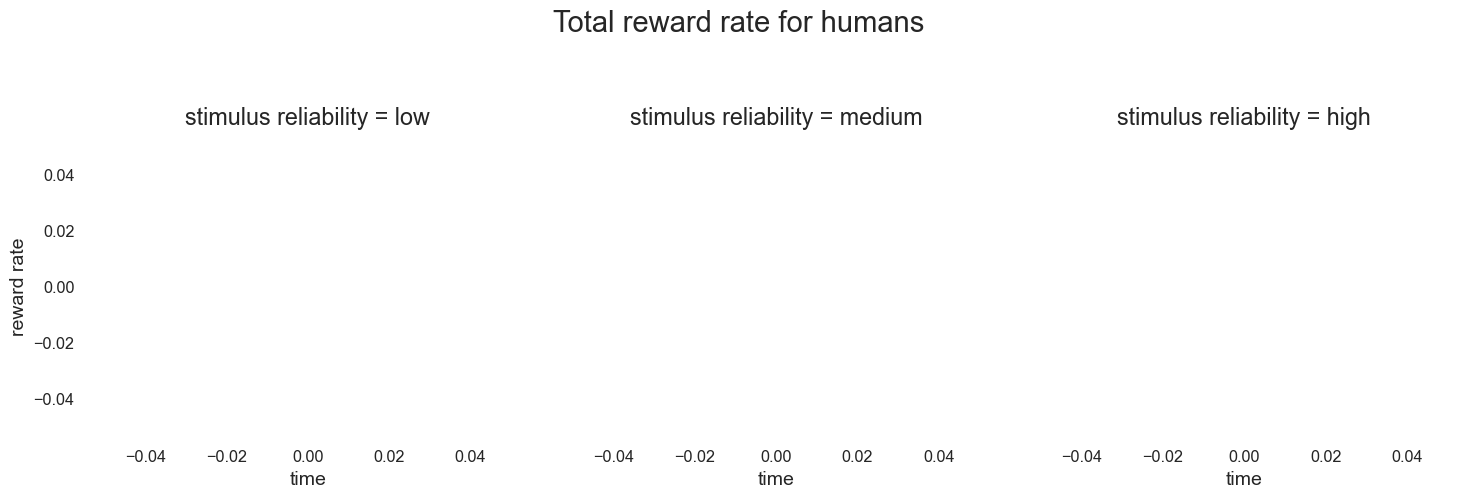

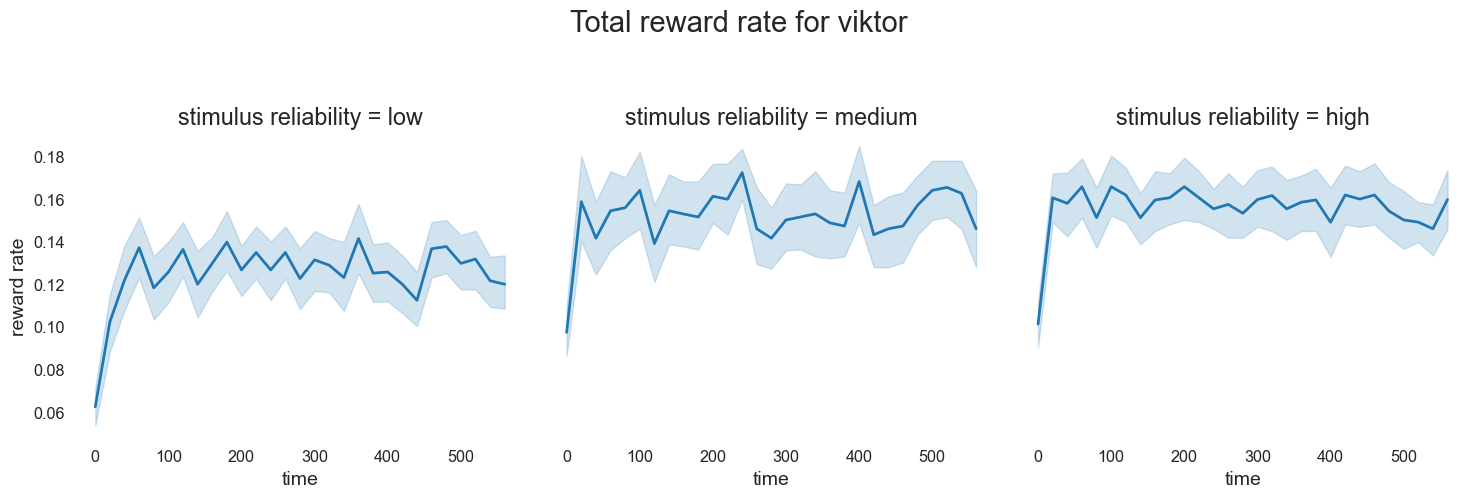

In [43]:
%%capture --no-display
for subject in subjects:
    ax = plot_reward_rates_in_block(filter_df(df, conds = {'subject': subject}), title =f'Total reward rate for {subject}', min_obs = 20, bin_kwargs = dict(bins = list(range(0, 60, 20)) + list(range(60, 600, 20))))

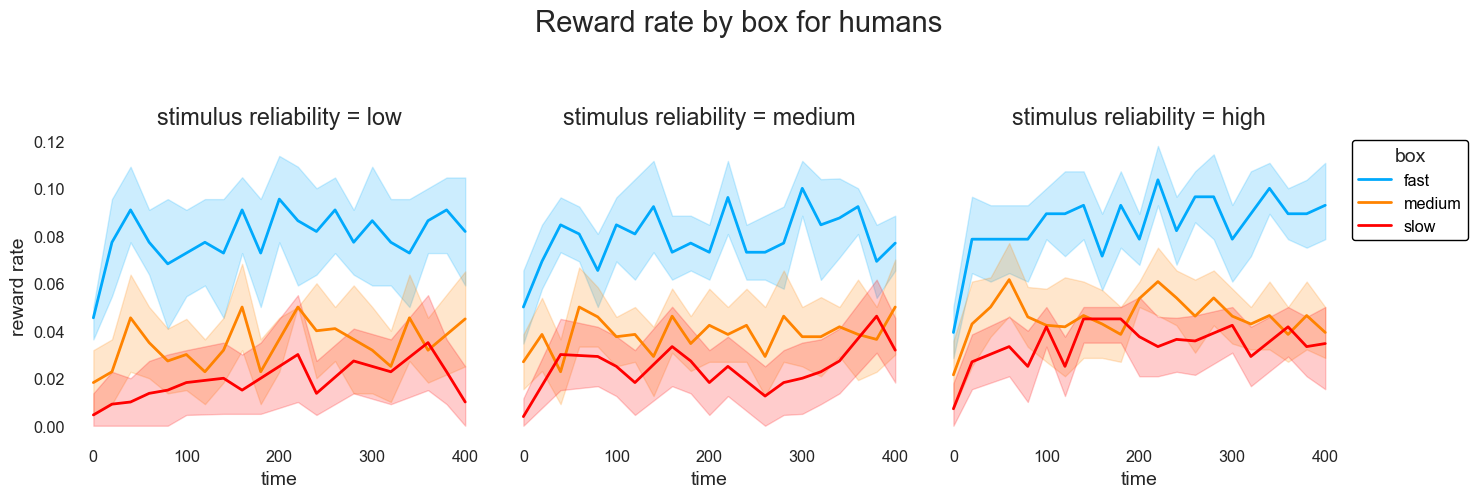

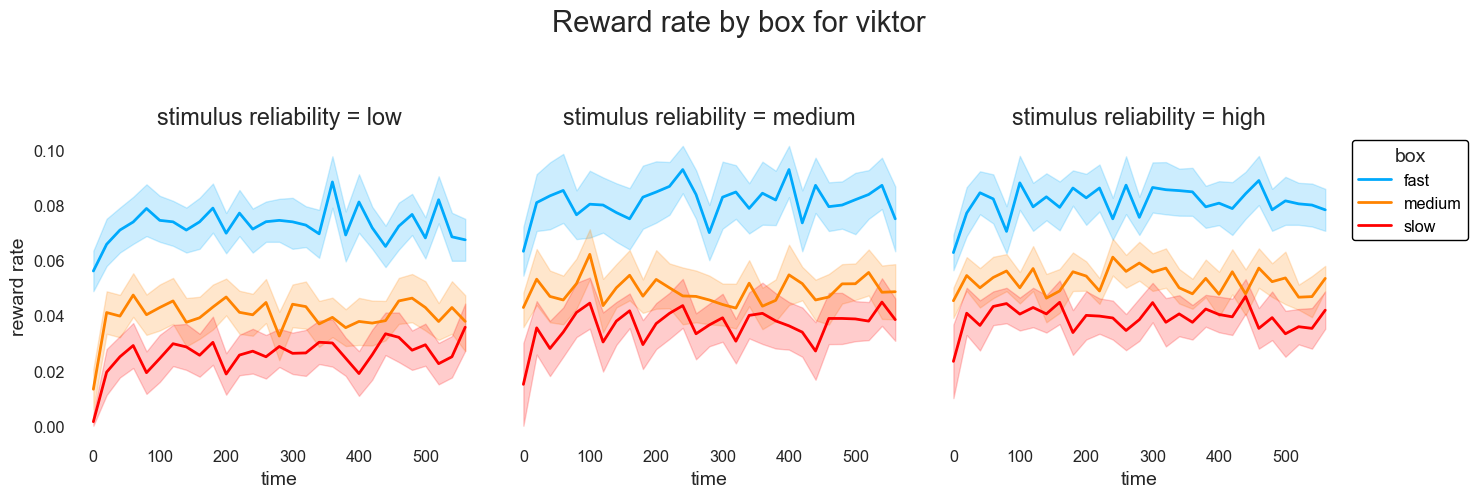

In [42]:
%%capture --no-display
for subject in subjects:
    ax = plot_reward_rates_in_block(filter_df(df, conds = {'subject': subject}), by_box = True, title =f'Reward rate by box for {subject}', legend_kwargs = dict(loc="upper left", bbox_to_anchor = (1,1)), min_obs = 10, bin_kwargs = dict(bins = list(range(0, 60, 20)) + list(range(60, 600, 20))))

### Wait Time

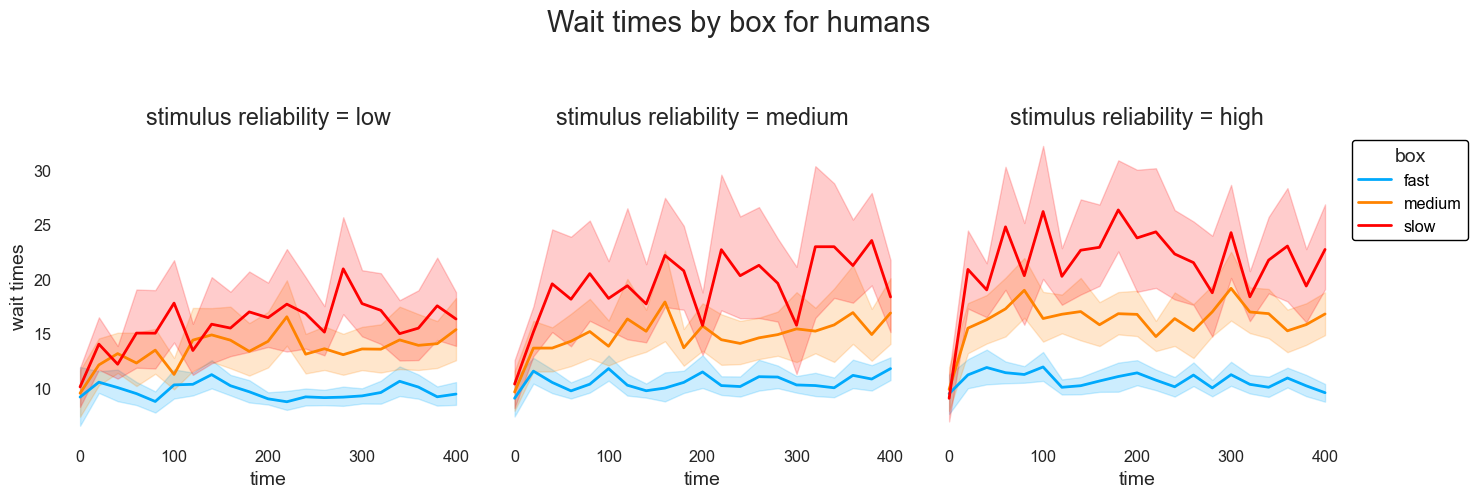

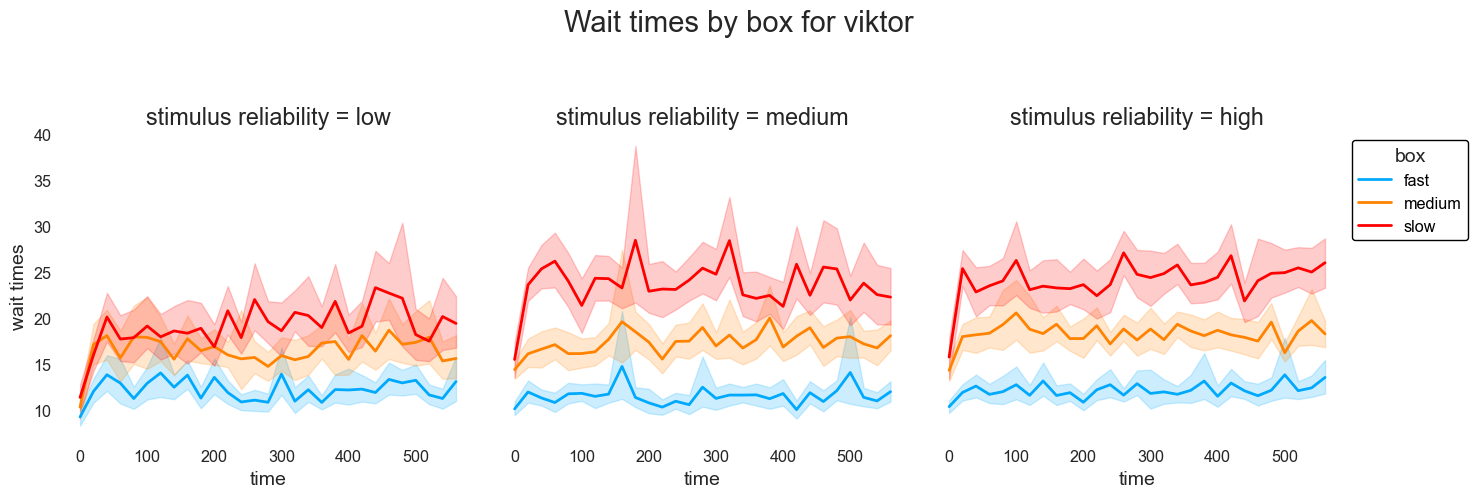

In [46]:
%%capture --no-display
for subject in subjects:
    ax = plot_quantity_in_block(filter_df(df, conds = {'subject': subject}), y = 'wait times', title =f'Wait times by box for {subject}', legend_kwargs = dict(loc="upper left", bbox_to_anchor = (1, 1)), bin_kwargs = dict(bins = list(range(0, 60, 20)) + list(range(60, 600, 20))))

### Matching Law

Matching should manifest as the ratio of reward rate and push rate being a constant across different boxes.

success
success


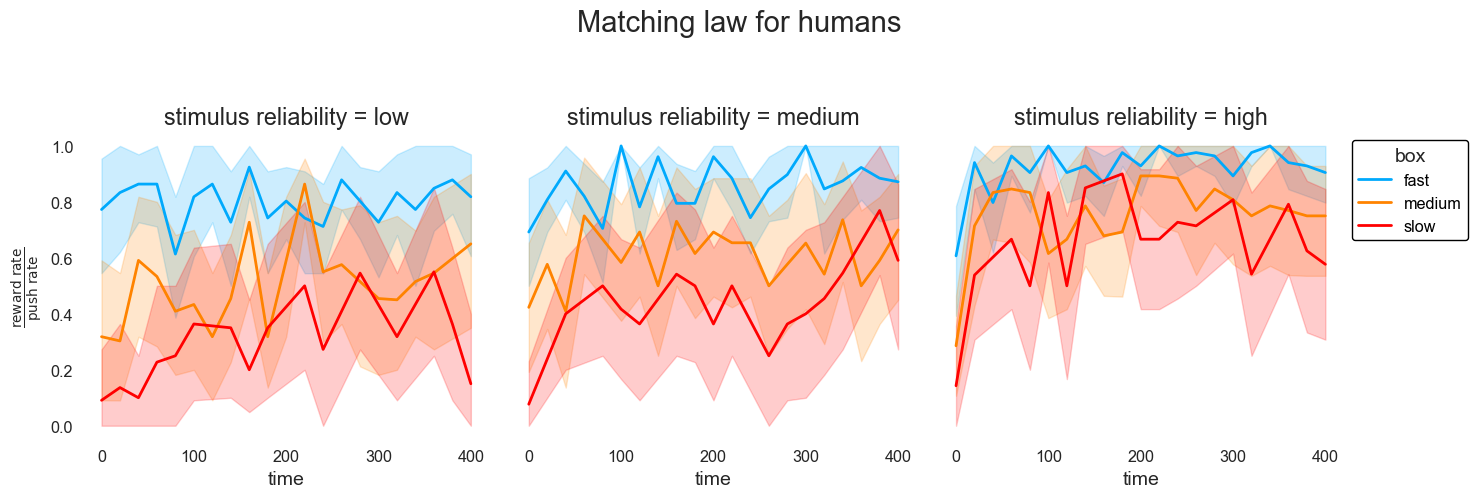

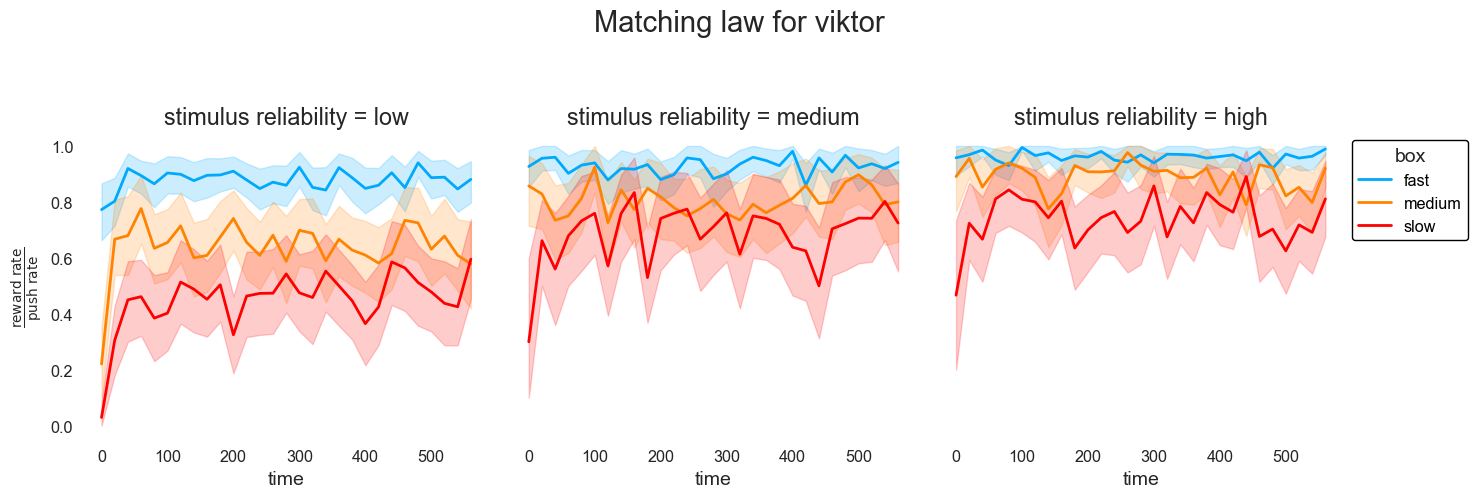

In [60]:
# %%capture --no-display
for subject in subjects:
    ax = plot_matching_law(filter_df(df, conds = {'subject': subject}), title =f'Matching law for {subject}', legend_kwargs = dict(loc="upper left", bbox_to_anchor = (1,1)), bin_kwargs = dict(bins = list(range(0, 60, 20)) + list(range(60, 600, 20))), min_obs = 10)

Taking the ratio is interesting, because it captures the notion of *efficiency* by essentially calculating the average reward per push, which can't exceed 1 since each push either receives a reward of size 1 or 0, but this efficiency can be hacked by a really cautious policy that pushes very slowly but gets rewarded every time. One workaround would be to square the denominator, thus penalizing such a policy and making an efficiency of 1 mean something.

### Information

The fisher information tells us how discriminable the parameters, such as the schedules and variance of the reward intervals, of the experiment are from similar parameters-- the higher the fisher information, the higher the theoretical limit on our knowledge or certainty about the parameters. This relationship is formally known as the Cramer-Rao lower bound, which states that the variance of any unbiased estimator can be no lower than the inverse fisher information. We derived the fisher information of the schedule ($\lambda$) as a function of the time between pushes, or the push interval ($t$), and the variance of reward intervals, or shape parameter ($\alpha$), using only observations about reward.

$$J(\lambda) = (\frac{t}{\lambda})^2 \frac{f^2(t|\lambda, \alpha)}{F(t|\lambda, \alpha)(1-F(t|\lambda, \alpha))}$$

Those familiar with signal detection theory will recognize the right term as being akin to $d^{\prime}$, or the signal-to-noise ratio. Here, we show the fisher information as a function of wait time for different boxes, along with the optimal waiting times that maximize the fisher information.

Finding optimal t for schedule 7
Argmax: 7.4097, Max value: 0.1303
Finding optimal t for schedule 14
Argmax: 14.8195, Max value: 0.0326
Finding optimal t for schedule 21
Argmax: 22.2292, Max value: 0.0145


C:\Users\noush\AppData\Local\Temp\ipykernel_13776\1972232535.py:4: RuntimeWarning: invalid value encountered in scalar divide
  return (t/schedule)**2*gamma.pdf(t, a = alpha, scale = scale)**2/(cdf*(1-cdf))


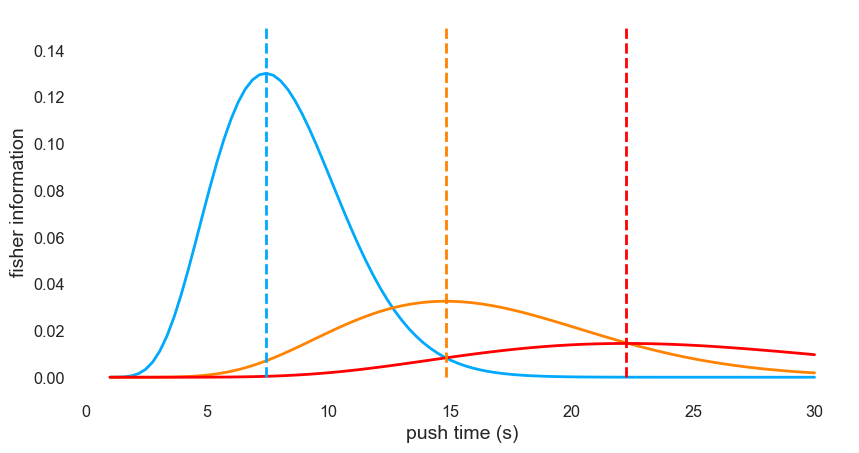

In [61]:
def fisher_info(t, schedule, alpha):
    scale = schedule / alpha
    cdf = gamma.cdf(t, a = alpha, scale = scale)
    return (t/schedule)**2*gamma.pdf(t, a = alpha, scale = scale)**2/(cdf*(1-cdf))

schedules = [7, 14, 21]
alpha = 10
optimal_fisher_t = {}
optimal_fisher_info = {}
for schedule in schedules:
    print(f'Finding optimal t for schedule {schedule}')
    res = minimize_scalar(lambda x: -fisher_info(x, schedule, alpha))
    # res = minimize_scalar(lambda x: -gamma.pdf(x, a = alpha, scale = schedule / alpha))

    # Result
    x_max = res.x
    f_max = fisher_info(x_max, schedule, alpha)

    print(f"Argmax: {x_max:.4f}, Max value: {f_max:.4f}")
    optimal_fisher_info[schedule] = f_max
    optimal_fisher_t[schedule] = x_max

t = np.linspace(1,30, 100)
fig, ax = plt.subplots(figsize = (10, 5))
fishers = []
for schedule in schedules:
    fishers.append(fisher_info(t, schedule, alpha))
[ax.plot(t, fishers[j], label = schedules[j], color = BOX_COLORS[j]) for j in range(len(schedules))]
ax.set_ylabel("fisher information")
ax.set_xlabel("push time (s)")
ax.vlines(x = optimal_fisher_t.values(), ymin = 0, ymax = 0.15, color = BOX_COLORS, linestyle = '--', label = r'$t^*=\underset{t}{\mathrm{argmax}}J_{\lambda}(t)$')# ax.legend()
    # plt.savefig(os.path.join(FIGURES_DIR, f'fisher_alpha={alpha}'))

Notice the optimal wait times are close to the schedules. One might ask if these are related to any common statistics from the Gamma distribution, such as median or mode, but further inspection revealed that those statistics are actually less than these "fisher-optimal" wait times.

In [62]:
fisher_info, err_fisher= process_blocks(df, compute_fisher, use_tqdm=True)
extend_df(df, fisher_info, 'fisher');
# fisher_info_rate, err_fisher_rate= utils.data.process_blocks(df, utils.beliefs.compute_fisher, use_tqdm=True, rate = True)
# utils.data.extend_df(df, fisher_info_rate, 'fisher rate');

 27%|██▋       | 48/175 [00:00<00:01, 104.35it/s]D:\Foraging\src\foraging\utils\models.py:547: RuntimeWarning: divide by zero encountered in scalar divide
  return (t / latent) ** 2 * gamma.pdf(t, a=self.shape, scale=scale) ** 2 / (cdf * (1 - cdf))
 34%|███▎      | 59/175 [00:00<00:01, 83.41it/s] D:\Foraging\src\foraging\utils\models.py:547: RuntimeWarning: divide by zero encountered in scalar divide
  return (t / latent) ** 2 * gamma.pdf(t, a=self.shape, scale=scale) ** 2 / (cdf * (1 - cdf))
 39%|███▉      | 68/175 [00:00<00:01, 77.60it/s]D:\Foraging\src\foraging\utils\models.py:547: RuntimeWarning: divide by zero encountered in scalar divide
  return (t / latent) ** 2 * gamma.pdf(t, a=self.shape, scale=scale) ** 2 / (cdf * (1 - cdf))
D:\Foraging\src\foraging\utils\models.py:547: RuntimeWarning: divide by zero encountered in scalar divide
  return (t / latent) ** 2 * gamma.pdf(t, a=self.shape, scale=scale) ** 2 / (cdf * (1 - cdf))
 44%|████▍     | 77/175 [00:00<00:01, 74.70it/s]D:\For

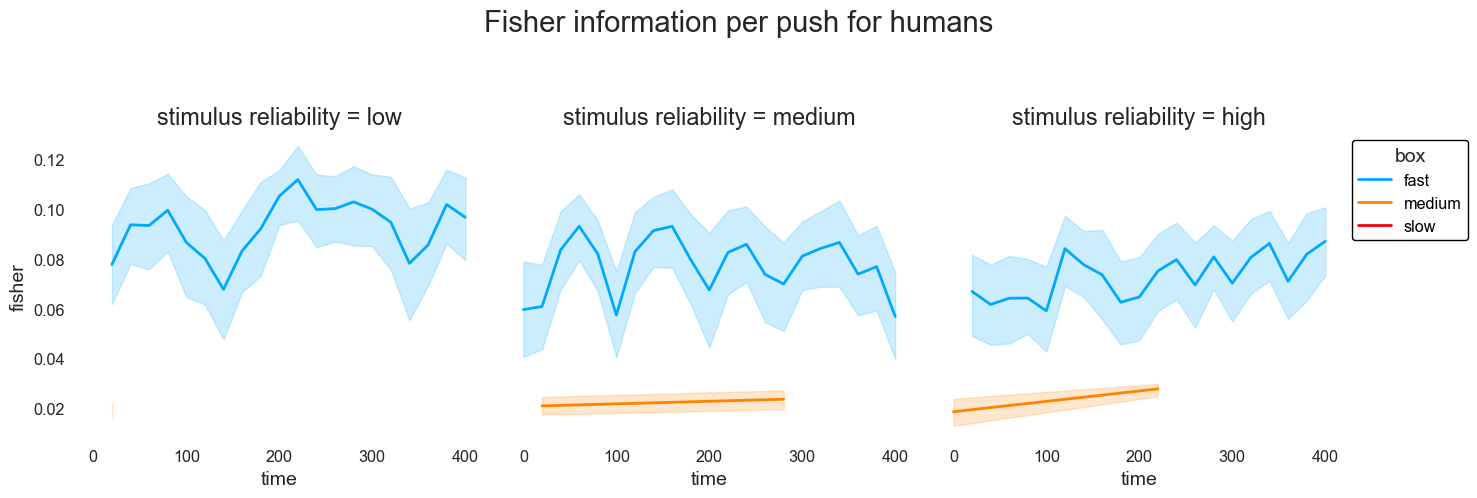

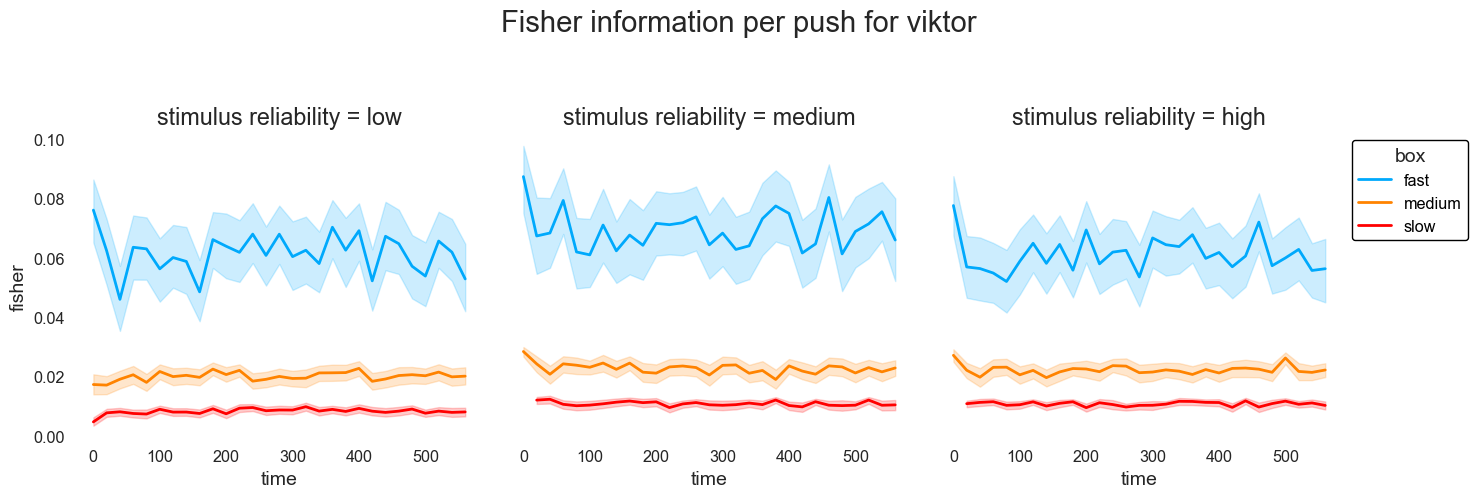

In [63]:
%%capture --no-display
for subject in subjects:
    ax = plot_quantity_in_block(filter_df(df, conds = {'subject': subject}), y = 'fisher', title =f'Fisher information per push for {subject}', legend_kwargs = dict(loc="upper left", bbox_to_anchor = (1, 1)), bin_kwargs = dict(bins = list(range(0, 60, 20)) + list(range(60, 600, 20))), min_obs = 20)

In [64]:
fisher_info_norm, err_fisher_norm= process_blocks(df, compute_normalized_fisher, use_tqdm=True, optimal_fisher = optimal_fisher_info)
extend_df(df, fisher_info_norm, 'normalized fisher');
# fisher_info_rate_norm, err_fisher_rate_norm= utils.data.process_blocks(df_gamma, utils.beliefs.compute_normalized_fisher, use_tqdm=True, optimal_fisher = optimal_fisher_rate_info, rate = True)
# utils.data.extend_df(df_gamma, fisher_info_rate_norm, 'normalized fisher rate');

 26%|██▋       | 46/175 [00:00<00:01, 97.64it/s] D:\Foraging\src\foraging\utils\models.py:547: RuntimeWarning: divide by zero encountered in scalar divide
  return (t / latent) ** 2 * gamma.pdf(t, a=self.shape, scale=scale) ** 2 / (cdf * (1 - cdf))
 32%|███▏      | 56/175 [00:00<00:01, 81.55it/s]D:\Foraging\src\foraging\utils\models.py:547: RuntimeWarning: divide by zero encountered in scalar divide
  return (t / latent) ** 2 * gamma.pdf(t, a=self.shape, scale=scale) ** 2 / (cdf * (1 - cdf))
 37%|███▋      | 65/175 [00:00<00:01, 75.73it/s]D:\Foraging\src\foraging\utils\models.py:547: RuntimeWarning: divide by zero encountered in scalar divide
  return (t / latent) ** 2 * gamma.pdf(t, a=self.shape, scale=scale) ** 2 / (cdf * (1 - cdf))
D:\Foraging\src\foraging\utils\models.py:547: RuntimeWarning: divide by zero encountered in scalar divide
  return (t / latent) ** 2 * gamma.pdf(t, a=self.shape, scale=scale) ** 2 / (cdf * (1 - cdf))
 42%|████▏     | 73/175 [00:00<00:01, 70.84it/s]D:\Fora

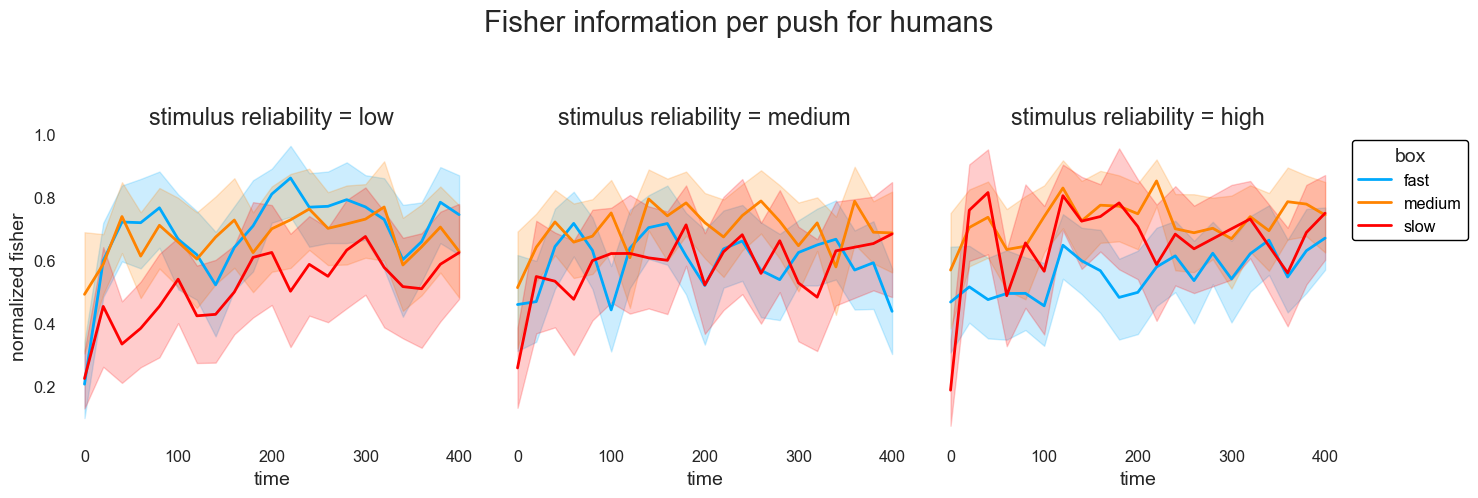

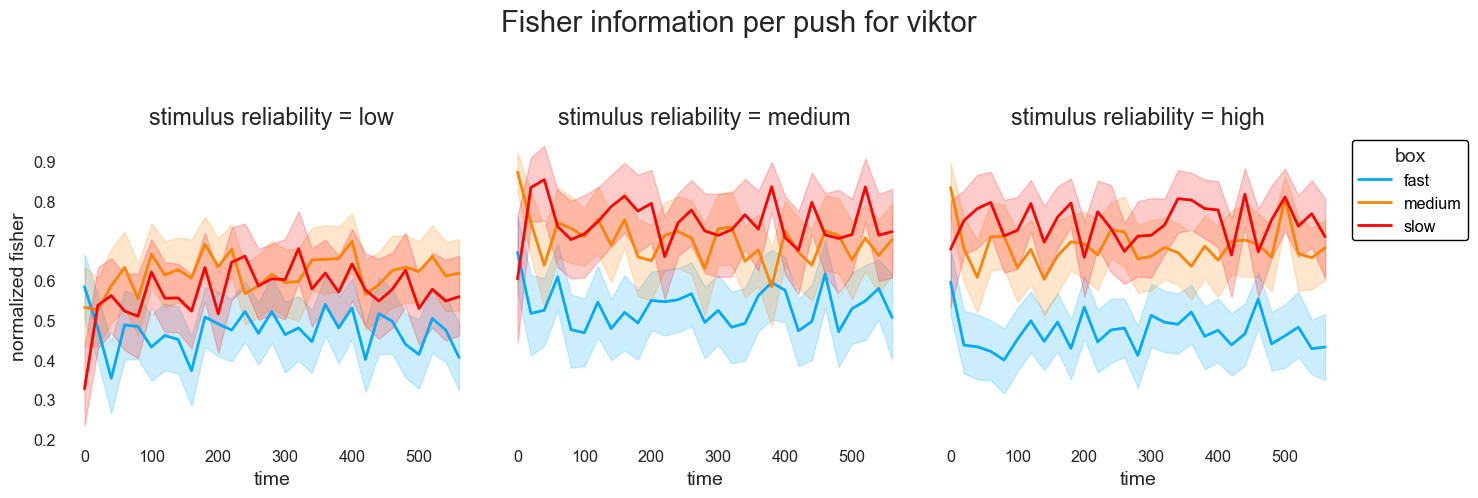

In [65]:
%%capture --no-display
for subject in subjects:
    ax = plot_quantity_in_block(filter_df(df, conds = {'subject': subject}), y = 'normalized fisher', title =f'Fisher information per push for {subject}', legend_kwargs = dict(loc="upper left", bbox_to_anchor = (1, 1)), bin_kwargs = dict(bins = list(range(0, 60, 20)) + list(range(60, 600, 20))),min_obs = 10)